# **Census Income (KDD) - Predicting Income Above/Below $50K**

**Students:** Hannah Bunnag & Zane Coons

**Course:** DATA 3421 - Data Mining, Summer 2026

**Dataset:** [Census-Income (KDD), UCI ML Repository, ID 117](https://archive.ics.uci.edu/dataset/117/census+income+kdd)

Research Question

Can demographic and employment-related attributes (age, education, occupation,
marital status, hours worked, etc.) collected in the U.S. Census Bureau's 1994-1995
Current Population Surveys predict whether an individual's total personal income
exceeds $50,000/year? This is a **binary classification** task.

Models

We build and compare three classifiers of increasing complexity - a single
**Decision Tree**, a bagged **Random Forest**, and a boosted **XGBoost**
model - following the same data preparation -> model -> compare -> conclude
structure used in prior labs. Given the severity of the class imbalance
(~94%/6%), every model is evaluated on precision/recall/F1/AUC for the
minority (`>$50K`) class rather than on accuracy alone.

---

In [ ]:
# Global imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Modeling (used starting in Section 5)
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve,
    RandomizedSearchCV, StratifiedKFold
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score,
    precision_score, recall_score, f1_score,
    average_precision_score, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
from scipy.stats import randint

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 150)
sns.set_style("whitegrid")

RANDOM_STATE = 2324  # keep consistent across the notebook for reproducibility

# NOTE: run this once if ucimlrepo isn't already installed:
# pip install ucimlrepo

---

## 1. Data Preparation:
- Data Exploration

In [ ]:
# Load the data
UCI_DATASET_ID = 117  # Census-Income (KDD)

dataset = fetch_ucirepo(id=UCI_DATASET_ID)
X_raw = dataset.data.features
y_raw = dataset.data.targets

df = pd.concat([X_raw, y_raw], axis=1)
TARGET_COL = "income"                  # confirmed directly (y_raw's single column)
INSTANCE_WEIGHT_COL = "MARSUPWRT"      # ucimlrepo's name for the Census Bureau's MARSUPWT

print(f"Shape: {df.shape}")
print(f"Target column: '{TARGET_COL}'")
print(f"Instance-weight column: '{INSTANCE_WEIGHT_COL}' (excluded from modeling per UCI docs)")
df.head(10)

Shape: (199523, 42)
Target column: 'income'
Instance-weight column: 'MARSUPWRT' (excluded from modeling per UCI docs)


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,AREORGN,ASEX,AUNMEM,AUNTYPE,AWKSTAT,CAPGAIN,GAPLOSS,DIVVAL,FILESTAT,GRINREG,GRINST,HHDFMX,HHDREL,MARSUPWRT,MIGMTR1,MIGMTR3,MIGMTR4,MIGSAME,MIGSUN,NOEMP,PARENT,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,1700.09,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,1053.55,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,991.95,NaN,NaN,NaN,Not in universe under 1 year old,NaN,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1758.14,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,1069.16,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
5,48,Private,40,10,Some college but no degree,Not in universe,Married-civilian spouse present,Entertainment,Professional specialty,Amer Indian Aleut or Eskimo,All other,Female,No,Not in universe,Full-time schedules,0,0,0,Joint both under 65,Not in universe,Not in universe,Spouse of householder,Spouse of householder,162.61,NaN,NaN,NaN,Not in universe under 1 year old,NaN,1,Not in universe,Philippines,United-States,United-States,Native- Born in the United States,2,Not in universe,2,52,1200,95,-50000
6,42,Private,34,3,Bachelors degree(BA AB BS),Not in universe,Married-civilian spouse present,Finance insurance and real estate,Executive admin and managerial,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,5178,0,0,Joint both under 65,Not in universe,Not in universe,Householder,Householder,1535.86,Nonmover,Nonmover,Nonmover,Yes,Not in universe,6,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
7,28,Private,4,40,High school graduate,Not in universe,Never married,Construction,Handlers equip cleaners etc,White,All other,Female,Not in universe,Job loser - on layoff,Unemployed full-time,0,0,0,Single,Not in universe,Not in universe,Secondary individual,Nonrelative of house

## Feature Dictionary


In [ ]:
# Feature dictionary: code -> plain-language description, sourced from the
# UCI Census-Income (KDD) documentation's internal column-name crosswalk
feature_dictionary = {
    "AAGE":      "Age",
    "ACLSWKR":   "Class of worker",
    "ADTINK":    "Industry code (documented as ADTIND)",
    "ADTOCC":    "Occupation code",
    "AHGA":      "Education level",
    "AHSCOL":    "Enrolled in educational institution last week",
    "AMARITL":   "Marital status",
    "AMJIND":    "Major industry code",
    "AMJOCC":    "Major occupation code",
    "ARACE":     "Race",
    "AREORGN":   "Hispanic origin",
    "ASEX":      "Sex",
    "AUNMEM":    "Member of a labor union",
    "AUNTYPE":   "Reason for unemployment",
    "AWKSTAT":   "Full or part time employment status",
    "CAPGAIN":   "Capital gains",
    "GAPLOSS":   "Capital losses (documented as CAPLOSS)",
    "DIVVAL":    "Dividends from stocks",
    "FILESTAT":  "Tax filer status",
    "GRINREG":   "Region of previous residence",
    "GRINST":    "State of previous residence",
    "HHDFMX":    "Detailed household and family status",
    "HHDREL":    "Detailed household summary in household",
    "MARSUPWRT": "Instance weight (documented as MARSUPWT) - excluded from modeling",
    "MIGMTR1":   "Migration code, change in MSA",
    "MIGMTR3":   "Migration code, change in region",
    "MIGMTR4":   "Migration code, move within region",
    "MIGSAME":   "Lived in this house 1 year ago",
    "MIGSUN":    "Migration, previous residence in Sun Belt",
    "NOEMP":     "Number of persons worked for employer",
    "PARENT":    "Family members under 18",
    "PEFNTVTY":  "Country of birth, father",
    "PEMNTVTY":  "Country of birth, mother",
    "PENATVTY":  "Country of birth, self",
    "PRCITSHP":  "Citizenship",
    "SEOTR":     "Own business or self-employed",
    "VETQVA":    "Fill inc. questionnaire for veteran's admin",
    "VETYN":     "Veterans benefits",
    "WKSWORK":   "Weeks worked in year",
    "AHRSPAY":   "Wage per hour",
    "year":      "Survey year (94 = 1994, 95 = 1995)",
    "income":    "TARGET - income class (above/below $50,000/year)",
}

# Build the reference table: code, description, role, and inferred type
data_dict = pd.DataFrame({
    "Code": list(feature_dictionary.keys()),
    "Description": list(feature_dictionary.values()),
})

data_dict["Role"] = np.select(
    [data_dict["Code"] == "income", data_dict["Code"] == "MARSUPWRT"],
    ["Target", "Excluded (weighting only)"],
    default="Feature"
)

# Reclassified numeric/categorical
true_numeric_cols = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY"]
data_dict["Type"] = np.where(
    data_dict["Code"].isin(true_numeric_cols), "Numeric",
    np.where(data_dict["Role"] == "Target", "Target (binary)", "Categorical")
)

data_dict = data_dict[["Code", "Description", "Role", "Type"]].reset_index(drop=True)
data_dict

,Code,Description,Role,Type
0,AAGE,Age,Feature,Numeric
1,ACLSWKR,Class of worker,Feature,Categorical
2,ADTINK,Industry code (documented as ADTIND),Feature,Categorical
3,ADTOCC,Occupation code,Feature,Categorical
4,AHGA,Education level,Feature,Categorical
5,AHSCOL,Enrolled in educational institution last week,Feature,Categorical
6,AMARITL,Marital status,Feature,Categorical
7,AMJIND,Major industry code,Feature,Categorical
8,AMJOCC,Major occupation code,Feature,Categorical
9,ARACE,Race,Feature,Categorical


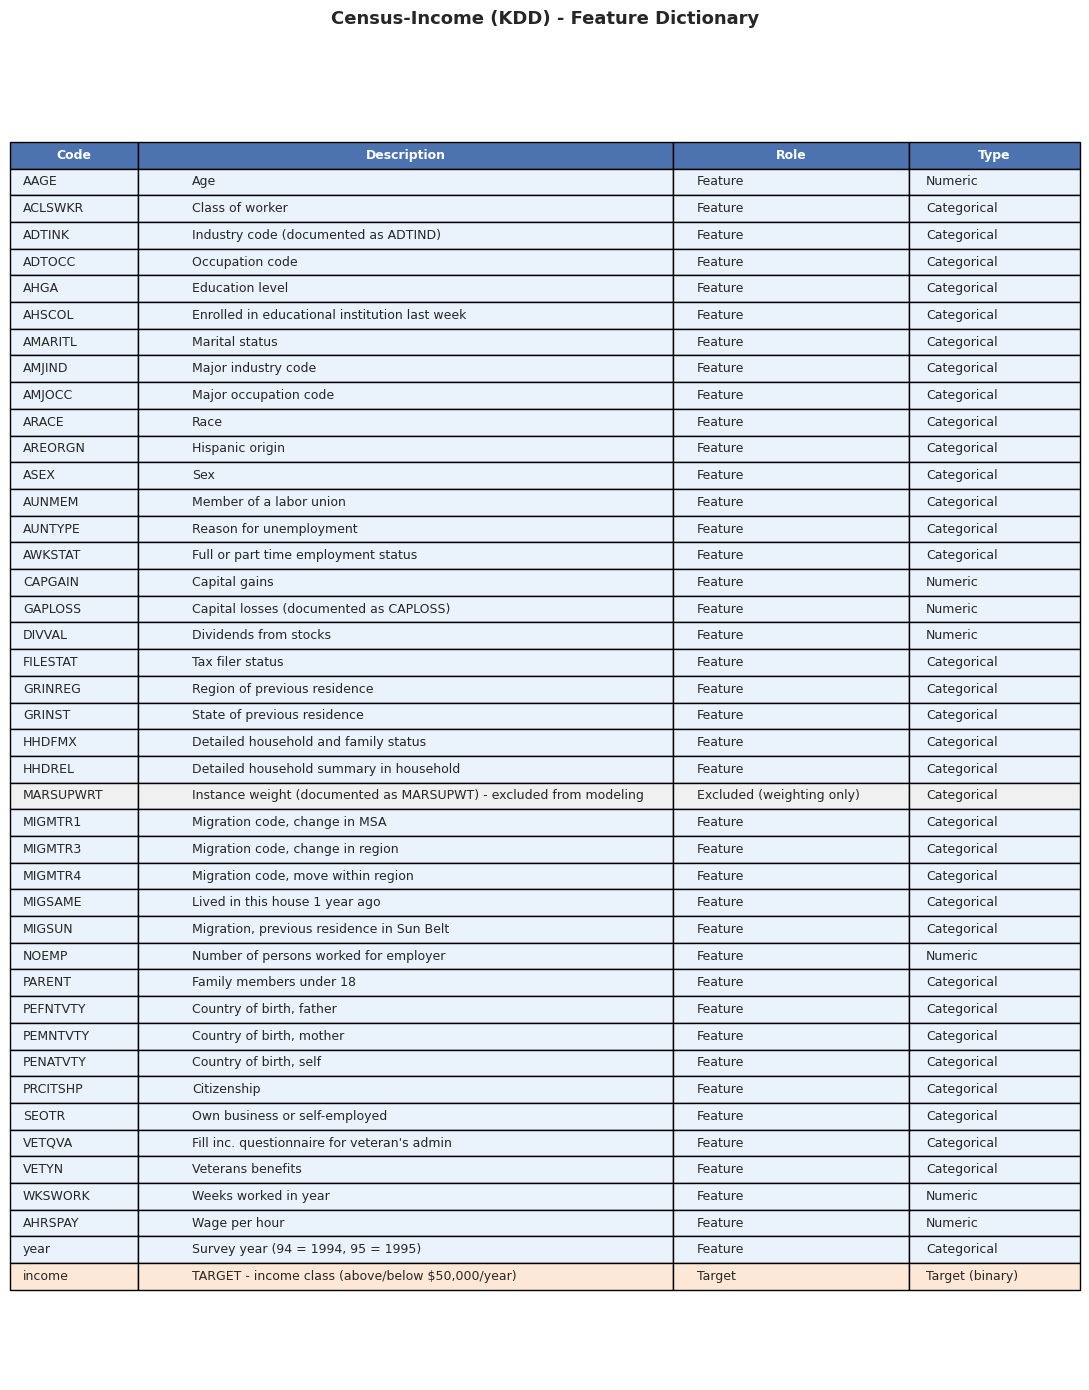

In [ ]:
# Visual reference chart: color-coded by Role, for quick scanning
fig, ax = plt.subplots(figsize=(11, 14))
ax.axis("off")

role_colors = {
    "Feature": "#EAF2FB",
    "Target": "#FDE8D7",
    "Excluded (weighting only)": "#F0F0F0"
}
cell_colors = [[role_colors[row.Role]] * 4 for row in data_dict.itertuples()]

table = ax.table(
    cellText=data_dict.values,
    colLabels=data_dict.columns,
    cellColours=cell_colors,
    cellLoc="left",
    loc="center",
    colWidths=[0.12, 0.5, 0.22, 0.16]
)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.3)

for j in range(4):
    table[(0, j)].set_facecolor("#4C72B0")
    table[(0, j)].set_text_props(color="white", weight="bold")

plt.title("Census-Income (KDD) - Feature Dictionary", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.show()

### 1.1 Dataset Structure

In [ ]:
# Full structural summary
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199523 entries, 0 to 199522
Data columns (total 42 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   AAGE       199523 non-null  int64  
 1   ACLSWKR    199523 non-null  str    
 2   ADTINK     199523 non-null  int64  
 3   ADTOCC     199523 non-null  int64  
 4   AHGA       199523 non-null  str    
 5   AHSCOL     199523 non-null  str    
 6   AMARITL    199523 non-null  str    
 7   AMJIND     199523 non-null  str    
 8   AMJOCC     199523 non-null  str    
 9   ARACE      199523 non-null  str    
 10  AREORGN    199523 non-null  str    
 11  ASEX       199523 non-null  str    
 12  AUNMEM     199523 non-null  str    
 13  AUNTYPE    199523 non-null  str    
 14  AWKSTAT    199523 non-null  str    
 15  CAPGAIN    199523 non-null  int64  
 16  GAPLOSS    199523 non-null  int64  
 17  DIVVAL     199523 non-null  int64  
 18  FILESTAT   199523 non-null  str    
 19  GRINREG    199523 non-null  str   

In [ ]:
# Numeric summary - only meaningful for columns pandas actually inferred as numeric
df.describe().T

,count,mean,std,min,25%,50%,75%,max
AAGE,199523.0,34.494199,22.310895,0.00,15.000,33.00,50.00,90.0
ADTINK,199523.0,15.352320,18.067129,0.00,0.000,0.00,33.00,51.0
ADTOCC,199523.0,11.306556,14.454204,0.00,0.000,0.00,26.00,46.0
CAPGAIN,199523.0,434.718990,4697.531280,0.00,0.000,0.00,0.00,99999.0
GAPLOSS,199523.0,37.313788,271.896428,0.00,0.000,0.00,0.00,4608.0
DIVVAL,199523.0,197.529533,1984.163658,0.00,0.000,0.00,0.00,99999.0
MARSUPWRT,199523.0,1740.380269,993.768156,37.87,1061.615,1618.31,2188.61,18656.3
NOEMP,199523.0,1.956180,2.365126,0.00,0.000,1.00,4.00,6.0
SEOTR,199523.0,0.175438,0.553694,0.00,0.000,0.00,0.00,2.0
VETYN,199523.0,1.514833,0.851473,0.00,2.000,2.00,2.00,2.0


In [ ]:
# Explicit dtype breakdown, since df.info() output is long with 42 columns
dtype_counts = df.dtypes.value_counts()
print("Column count by inferred dtype:")
print(dtype_counts)
print()

numeric_cols_raw = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols_raw = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols_raw)}): {numeric_cols_raw}")
print()
print(f"Categorical/object columns ({len(categorical_cols_raw)}): {categorical_cols_raw}")

Column count by inferred dtype:
str        29
int64      12
float64     1
Name: count, dtype: int64

Numeric columns (13): ['AAGE', 'ADTINK', 'ADTOCC', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'MARSUPWRT', 'NOEMP', 'SEOTR', 'VETYN', 'WKSWORK', 'AHRSPAY', 'year']

Categorical/object columns (29): ['ACLSWKR', 'AHGA', 'AHSCOL', 'AMARITL', 'AMJIND', 'AMJOCC', 'ARACE', 'AREORGN', 'ASEX', 'AUNMEM', 'AUNTYPE', 'AWKSTAT', 'FILESTAT', 'GRINREG', 'GRINST', 'HHDFMX', 'HHDREL', 'MIGMTR1', 'MIGMTR3', 'MIGMTR4', 'MIGSAME', 'MIGSUN', 'PARENT', 'PEFNTVTY', 'PEMNTVTY', 'PENATVTY', 'PRCITSHP', 'VETQVA', 'income']


### 1.2 Target Variable - `income`

In [ ]:
print("Raw target class labels:")
print(df[TARGET_COL].unique())
print()
print("Class counts:")
print(df[TARGET_COL].value_counts())
print()
print("Class proportions:")
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(2).astype(str) + " %")

Raw target class labels:
<StringArray>
['-50000', ' 50000+.']
Length: 2, dtype: str

Class counts:
income
-50000      187141
 50000+.     12382
Name: count, dtype: int64

Class proportions:
income
-50000      93.79 %
 50000+.     6.21 %
Name: proportion, dtype: str


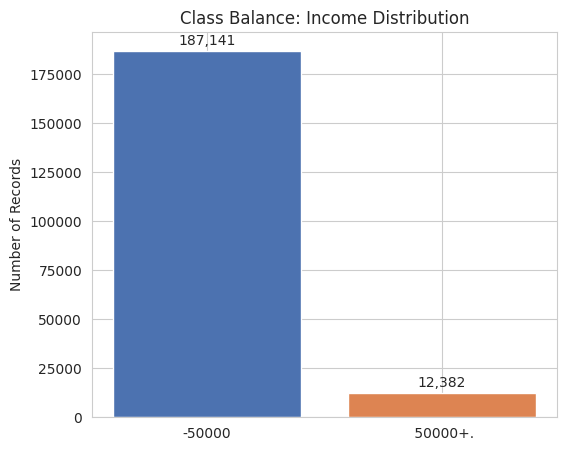

In [ ]:
# Visualize the class balance directly
class_counts = df[TARGET_COL].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(class_counts.index.astype(str), class_counts.values, color=["#4C72B0", "#DD8452"])
plt.ylabel("Number of Records")
plt.title("Class Balance: Income Distribution")
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 3000, f"{v:,}", ha="center")
plt.show()

---

## 2. Data Cleaning

In [ ]:
# Drop the instance-weight column from the modeling frame, keep it aside
# INSTANCE_WEIGHT_COL = "MARSUPWRT" <- Defined above now

instance_weights = df[INSTANCE_WEIGHT_COL].copy()
df_model = df.drop(columns=[INSTANCE_WEIGHT_COL])

print(f"Dropped '{INSTANCE_WEIGHT_COL}' from modeling frame.")
print(f"df_model shape: {df_model.shape}")

Dropped 'MARSUPWRT' from modeling frame.
df_model shape: (199523, 41)


In [ ]:
# Category 1: native missing values
null_counts = df_model.isnull().sum()
null_pct = (null_counts / len(df_model) * 100).round(2)

null_summary = (
    pd.DataFrame({"n_missing": null_counts, "pct_missing": null_pct})
    .query("n_missing > 0")
    .sort_values("pct_missing", ascending=False)
)

print(f"Columns with native missing values: {len(null_summary)} / {df_model.shape[1]}")
null_summary

Columns with native missing values: 8 / 41


,n_missing,pct_missing
MIGMTR1,99696,49.97
MIGMTR3,99696,49.97
MIGMTR4,99696,49.97
MIGSUN,99696,49.97
PEFNTVTY,6713,3.36
PEMNTVTY,6119,3.07
PENATVTY,3393,1.70
GRINST,708,0.35


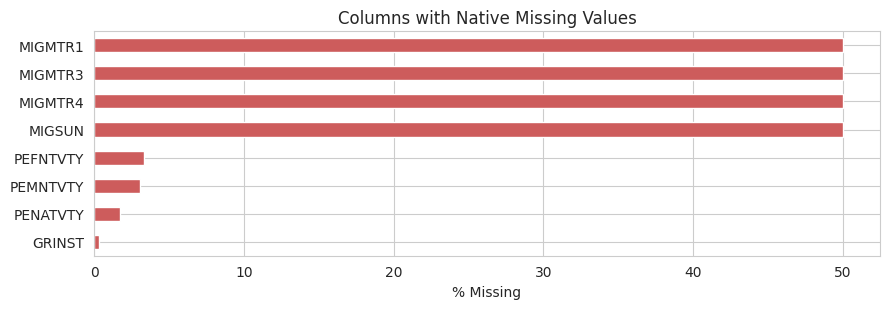

In [ ]:
fig, ax = plt.subplots(figsize=(9, max(3, len(null_summary) * 0.4)))
null_summary["pct_missing"].sort_values().plot(kind="barh", ax=ax, color="indianred")
ax.set_xlabel("% Missing")
ax.set_title("Columns with Native Missing Values")
plt.tight_layout()
plt.show()

In [ ]:
# Category 2: "Not in universe" - confirmed as a category, not noise
niu_counts = df_model.astype(str).apply(lambda col: col.str.strip().eq("Not in universe").sum())
niu_counts = niu_counts[niu_counts > 0].sort_values(ascending=False)

print(f"Columns containing a 'Not in universe' category: {len(niu_counts)}")
niu_counts

Columns containing a 'Not in universe' category: 13


VETQVA     197539
AUNTYPE    193453
AHSCOL     186943
GRINREG    183750
GRINST     183750
AUNMEM     180459
PARENT     144232
AMJOCC     100684
ACLSWKR    100245
MIGSUN      84054
MIGMTR1      1516
MIGMTR3      1516
MIGMTR4      1516
dtype: int64

### Checking the Migration Columns Specifically

all show ~50% native missing
suspiciously identical across four unrelated columns,
`MIGSAME` ("lived in
this house 1 year ago") is the natural column to check this against.

In [ ]:
# Cross-check: is the migration-detail missingness explained by a MIGSAME skip pattern?
print(df_model["MIGSAME"].value_counts())
print()

migsame_vs_missing = df_model.groupby(df_model["MIGSAME"], dropna=False)["MIGMTR1"].apply(
    lambda s: s.isnull().sum()
)
print("Missing MIGMTR1 count, broken out by MIGSAME response:")
print(migsame_vs_missing)

MIGSAME
Not in universe under 1 year old    101212
Yes                                  82538
No                                   15773
Name: count, dtype: int64

Missing MIGMTR1 count, broken out by MIGSAME response:
MIGSAME
No                                      0
Not in universe under 1 year old    99696
Yes                                     0
Name: MIGMTR1, dtype: int64


so this is a structural "not applicable" pattern, not missing data to impute

In [ ]:
migration_cols = ["MIGMTR1", "MIGMTR3", "MIGMTR4", "MIGSUN"]
df_clean = df_model.copy()

for col in migration_cols:
    df_clean[col] = df_clean[col].fillna("Not in universe")

print(df_clean[migration_cols].isnull().sum())

MIGMTR1    0
MIGMTR3    0
MIGMTR4    0
MIGSUN     0
dtype: int64


### Genuine Missing Values - `PEFNTVTY`, `PEMNTVTY`, `PENATVTY`, `GRINST`

these four remaining columns are true missingness, filled with an
explicit `"Missing"` category rather than mode-imputed to avoid fabricating data

In [ ]:
genuine_missing_cols = ["PEFNTVTY", "PEMNTVTY", "PENATVTY", "GRINST"]

for col in genuine_missing_cols:
    df_clean[col] = df_clean[col].fillna("Missing")

print(df_clean[genuine_missing_cols].isnull().sum())
print()
print(f"Any remaining missing values in df_clean: {df_clean.isnull().sum().sum()}")

PEFNTVTY    0
PEMNTVTY    0
PENATVTY    0
GRINST      0
dtype: int64

Any remaining missing values in df_clean: 0


### Duplicate Rows

Checked on the cleaned frame. Given the dataset's heavily categorical,
low-cardinality composition, two different people sharing an identical row
is expected at this scale, not a sign of erroneous data collection.

In [ ]:
duplicate_count = df_clean.duplicated().sum()
print(f"Number of fully duplicated rows: {duplicate_count} ({duplicate_count / len(df_clean) * 100:.2f}% of rows)")

Number of fully duplicated rows: 46627 (23.37% of rows)


**Decision: duplicates are kept, not dropped.** With dozens of low-variance
categorical columns (many with only 2-3 levels, several `"Not in universe"`
for the large share of respondents outside the labor force), exact-row
coincidence across different people is expected here, there's no strong reason to treat a match as necessarily the
*same* record.

In [ ]:
print(f"Final df_clean shape: {df_clean.shape}")
print(f"Total missing values: {df_clean.isnull().sum().sum()}")
df_clean.head()

Final df_clean shape: (199523, 41)
Total missing values: 0


,AAGE,ACLSWKR,ADTINK,ADTOCC,AHGA,AHSCOL,AMARITL,AMJIND,AMJOCC,ARACE,AREORGN,ASEX,AUNMEM,AUNTYPE,AWKSTAT,CAPGAIN,GAPLOSS,DIVVAL,FILESTAT,GRINREG,GRINST,HHDFMX,HHDREL,MIGMTR1,MIGMTR3,MIGMTR4,MIGSAME,MIGSUN,NOEMP,PARENT,PEFNTVTY,PEMNTVTY,PENATVTY,PRCITSHP,SEOTR,VETQVA,VETYN,WKSWORK,AHRSPAY,year,income
0,73,Not in universe,0,0,High school graduate,Not in universe,Widowed,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Other Rel 18+ ever marr not in subfamily,Other relative of householder,Not in universe,Not in universe,Not in universe,Not in universe under 1 year old,Not in universe,0,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,0,95,-50000
1,58,Self-employed-not incorporated,4,34,Some college but no degree,Not in universe,Divorced,Construction,Precision production craft & repair,White,All other,Male,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Head of household,South,Arkansas,Householder,Householder,MSA to MSA,Same county,Same county,No,Yes,1,Not in universe,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,0,94,-50000
2,18,Not in universe,0,0,10th grade,High school,Never married,Not in universe or children,Not in universe,Asian or Pacific Islander,All other,Female,Not in universe,Not in universe,Not in labor force,0,0,0,Nonfiler,Not in universe,Not in universe,Child 18+ never marr Not in a subfamily,Child 18 or older,Not in universe,Not in universe,Not in universe,Not in universe under 1 year old,Not in universe,0,Not in universe,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,0,95,-50000
3,9,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000
4,10,Not in universe,0,0,Children,Not in universe,Never married,Not in universe or children,Not in universe,White,All other,Female,Not in universe,Not in universe,Children or Armed Forces,0,0,0,Nonfiler,Not in universe,Not in universe,Child <18 never marr not in subfamily,Child under 18 never married,Nonmover,Nonmover,Nonmover,Yes,Not in universe,0,Both parents present,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,0,94,-50000


---

## 3. Exploratory Data Analysis:

In [ ]:
# Define the working numeric/categorical column lists explicitly,
NUMERIC_COLS = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY"]
CATEGORICAL_COLS = [c for c in df_clean.columns if c not in NUMERIC_COLS + [TARGET_COL]]

print(f"Numeric columns ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical columns ({len(CATEGORICAL_COLS)}): {len(CATEGORICAL_COLS)} total")

Numeric columns (7): ['AAGE', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'NOEMP', 'WKSWORK', 'AHRSPAY']
Categorical columns (33): 33 total


### 3.1 Numeric Feature Distributions

Histograms for the seven true numeric fields, some
heavily zero-inflated

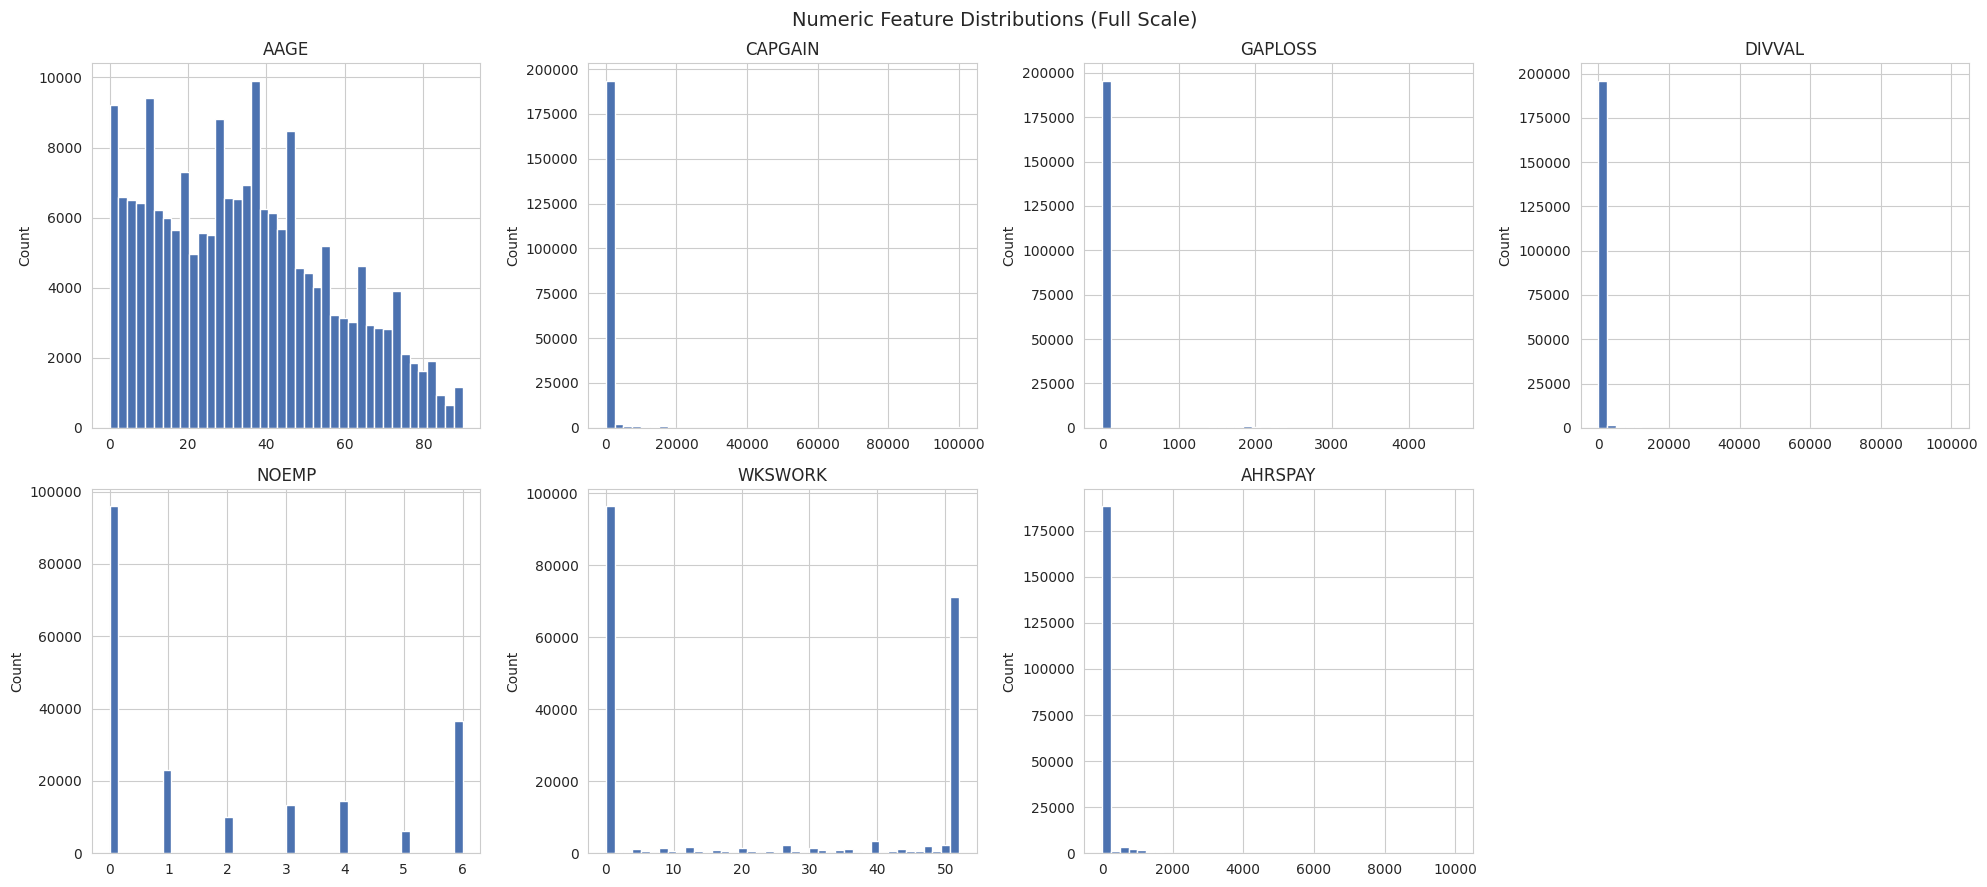

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for ax, col in zip(axes, NUMERIC_COLS):
    ax.hist(df_clean[col], bins=40, edgecolor="white", color="#4C72B0")
    ax.set_title(col)
    ax.set_ylabel("Count")

for j in range(len(NUMERIC_COLS), len(axes)):
    axes[j].axis("off")

plt.suptitle("Numeric Feature Distributions (Full Scale)", fontsize=14)
plt.tight_layout()
plt.show()

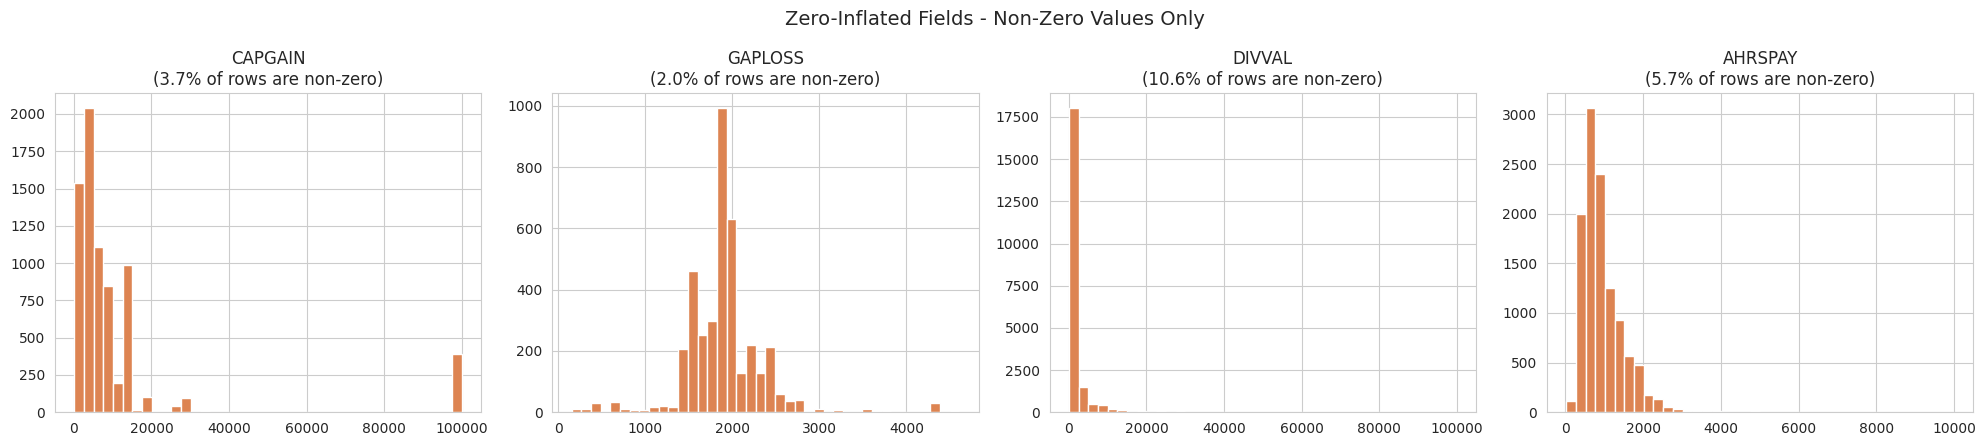

In [ ]:
# Zero-inflated fields are hard to read at full scale - re-plot the non-zero
# tail only, for the four fields where the median was 0
zero_inflated_cols = ["CAPGAIN", "GAPLOSS", "DIVVAL", "AHRSPAY"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, col in zip(axes, zero_inflated_cols):
    nonzero = df_clean.loc[df_clean[col] > 0, col]
    pct_nonzero = len(nonzero) / len(df_clean) * 100
    ax.hist(nonzero, bins=40, edgecolor="white", color="#DD8452")
    ax.set_title(f"{col}\n({pct_nonzero:.1f}% of rows are non-zero)")

plt.suptitle("Zero-Inflated Fields - Non-Zero Values Only", fontsize=14)
plt.tight_layout()
plt.show()

### 3.2 Outlier Detection

IQR-based check on the numeric fields, zero inflation causes high number of flagged outliers

In [ ]:
def iqr_outlier_count(series: pd.Series) -> tuple:
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = int(((series < lower) | (series > upper)).sum())
    return n_outliers, lower, upper

outlier_rows = []
for col in NUMERIC_COLS:
    n_out, lower, upper = iqr_outlier_count(df_clean[col])
    outlier_rows.append({
        "Feature": col,
        "n_outliers": n_out,
        "pct_outliers": round(n_out / len(df_clean) * 100, 2),
        "IQR_lower": round(lower, 2),
        "IQR_upper": round(upper, 2),
    })

outlier_summary = pd.DataFrame(outlier_rows).sort_values("pct_outliers", ascending=False)
outlier_summary

,Feature,n_outliers,pct_outliers,IQR_lower,IQR_upper
3,DIVVAL,21141,10.60,0.0,0.0
6,AHRSPAY,11304,5.67,0.0,0.0
1,CAPGAIN,7379,3.70,0.0,0.0
2,GAPLOSS,3906,1.96,0.0,0.0
0,AAGE,0,0.00,-37.5,102.5
4,NOEMP,0,0.00,-6.0,10.0
5,WKSWORK,0,0.00,-78.0,130.0


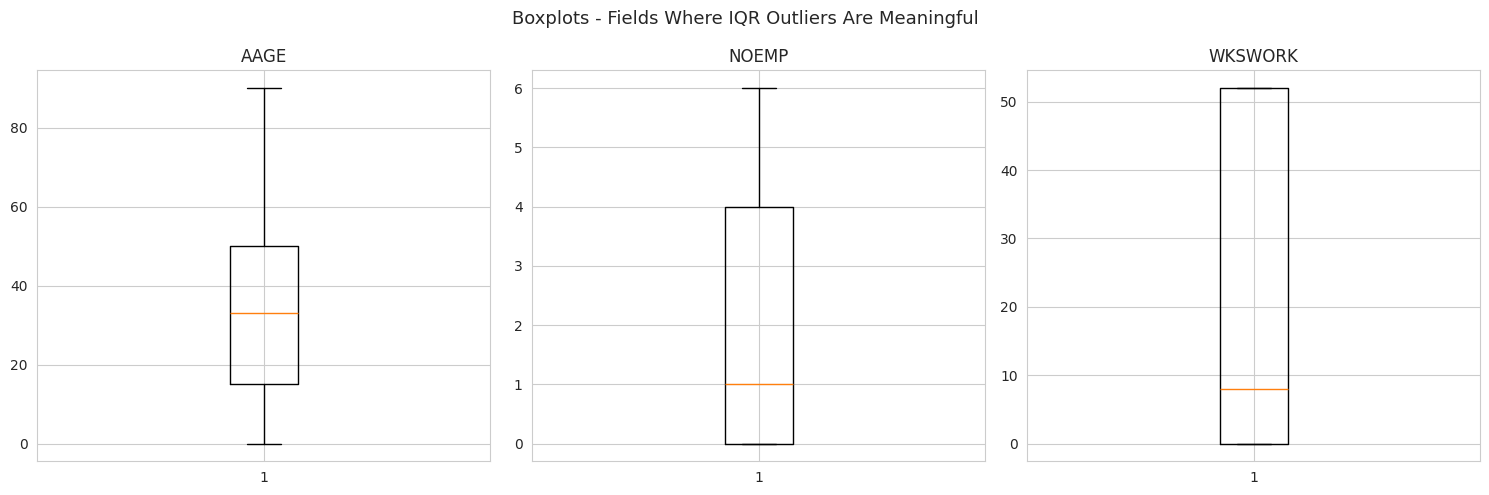

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["AAGE", "NOEMP", "WKSWORK"]):
    ax.boxplot(df_clean[col], vert=True)
    ax.set_title(col)

plt.suptitle("Boxplots - Fields Where IQR Outliers Are Meaningful", fontsize=13)
plt.tight_layout()
plt.show()

### 3.3 Correlation Matrix (Numeric Fields + Target)

numeric correlation matrix, target is binary 1/0

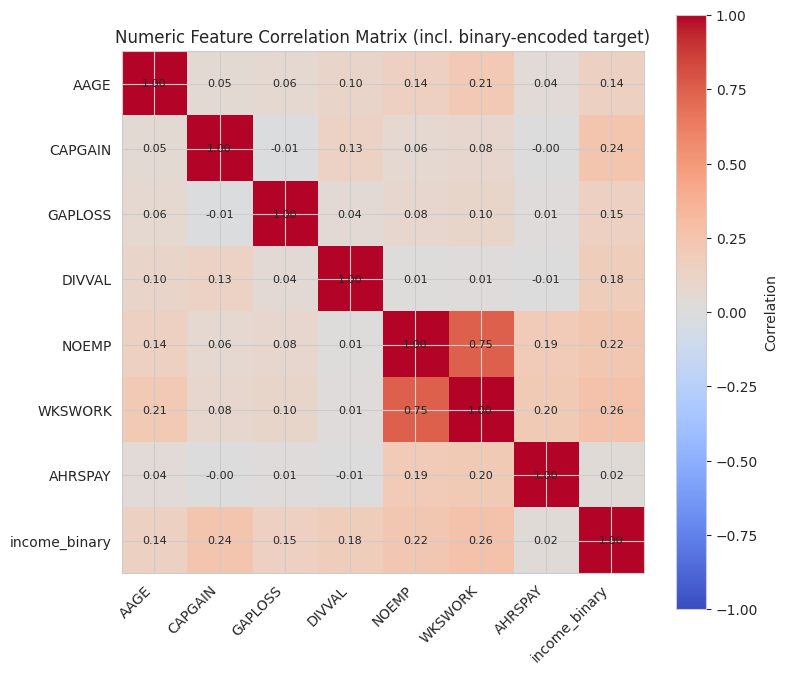

WKSWORK    0.262316
CAPGAIN    0.240725
NOEMP      0.222684
DIVVAL     0.175779
GAPLOSS    0.147417
AAGE       0.135720
AHRSPAY    0.024528
Name: income_binary, dtype: float64

In [ ]:
corr_df = df_clean[NUMERIC_COLS].copy()
corr_df["income_binary"] = (df_clean[TARGET_COL] == " 50000+.").astype(int)

corr_matrix = corr_df.corr()

plt.figure(figsize=(8, 7))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Numeric Feature Correlation Matrix (incl. binary-encoded target)")
plt.tight_layout()
plt.show()

corr_matrix["income_binary"].drop("income_binary").sort_values(ascending=False)

### 3.4 Categorical Features vs. Target
a few informative categories

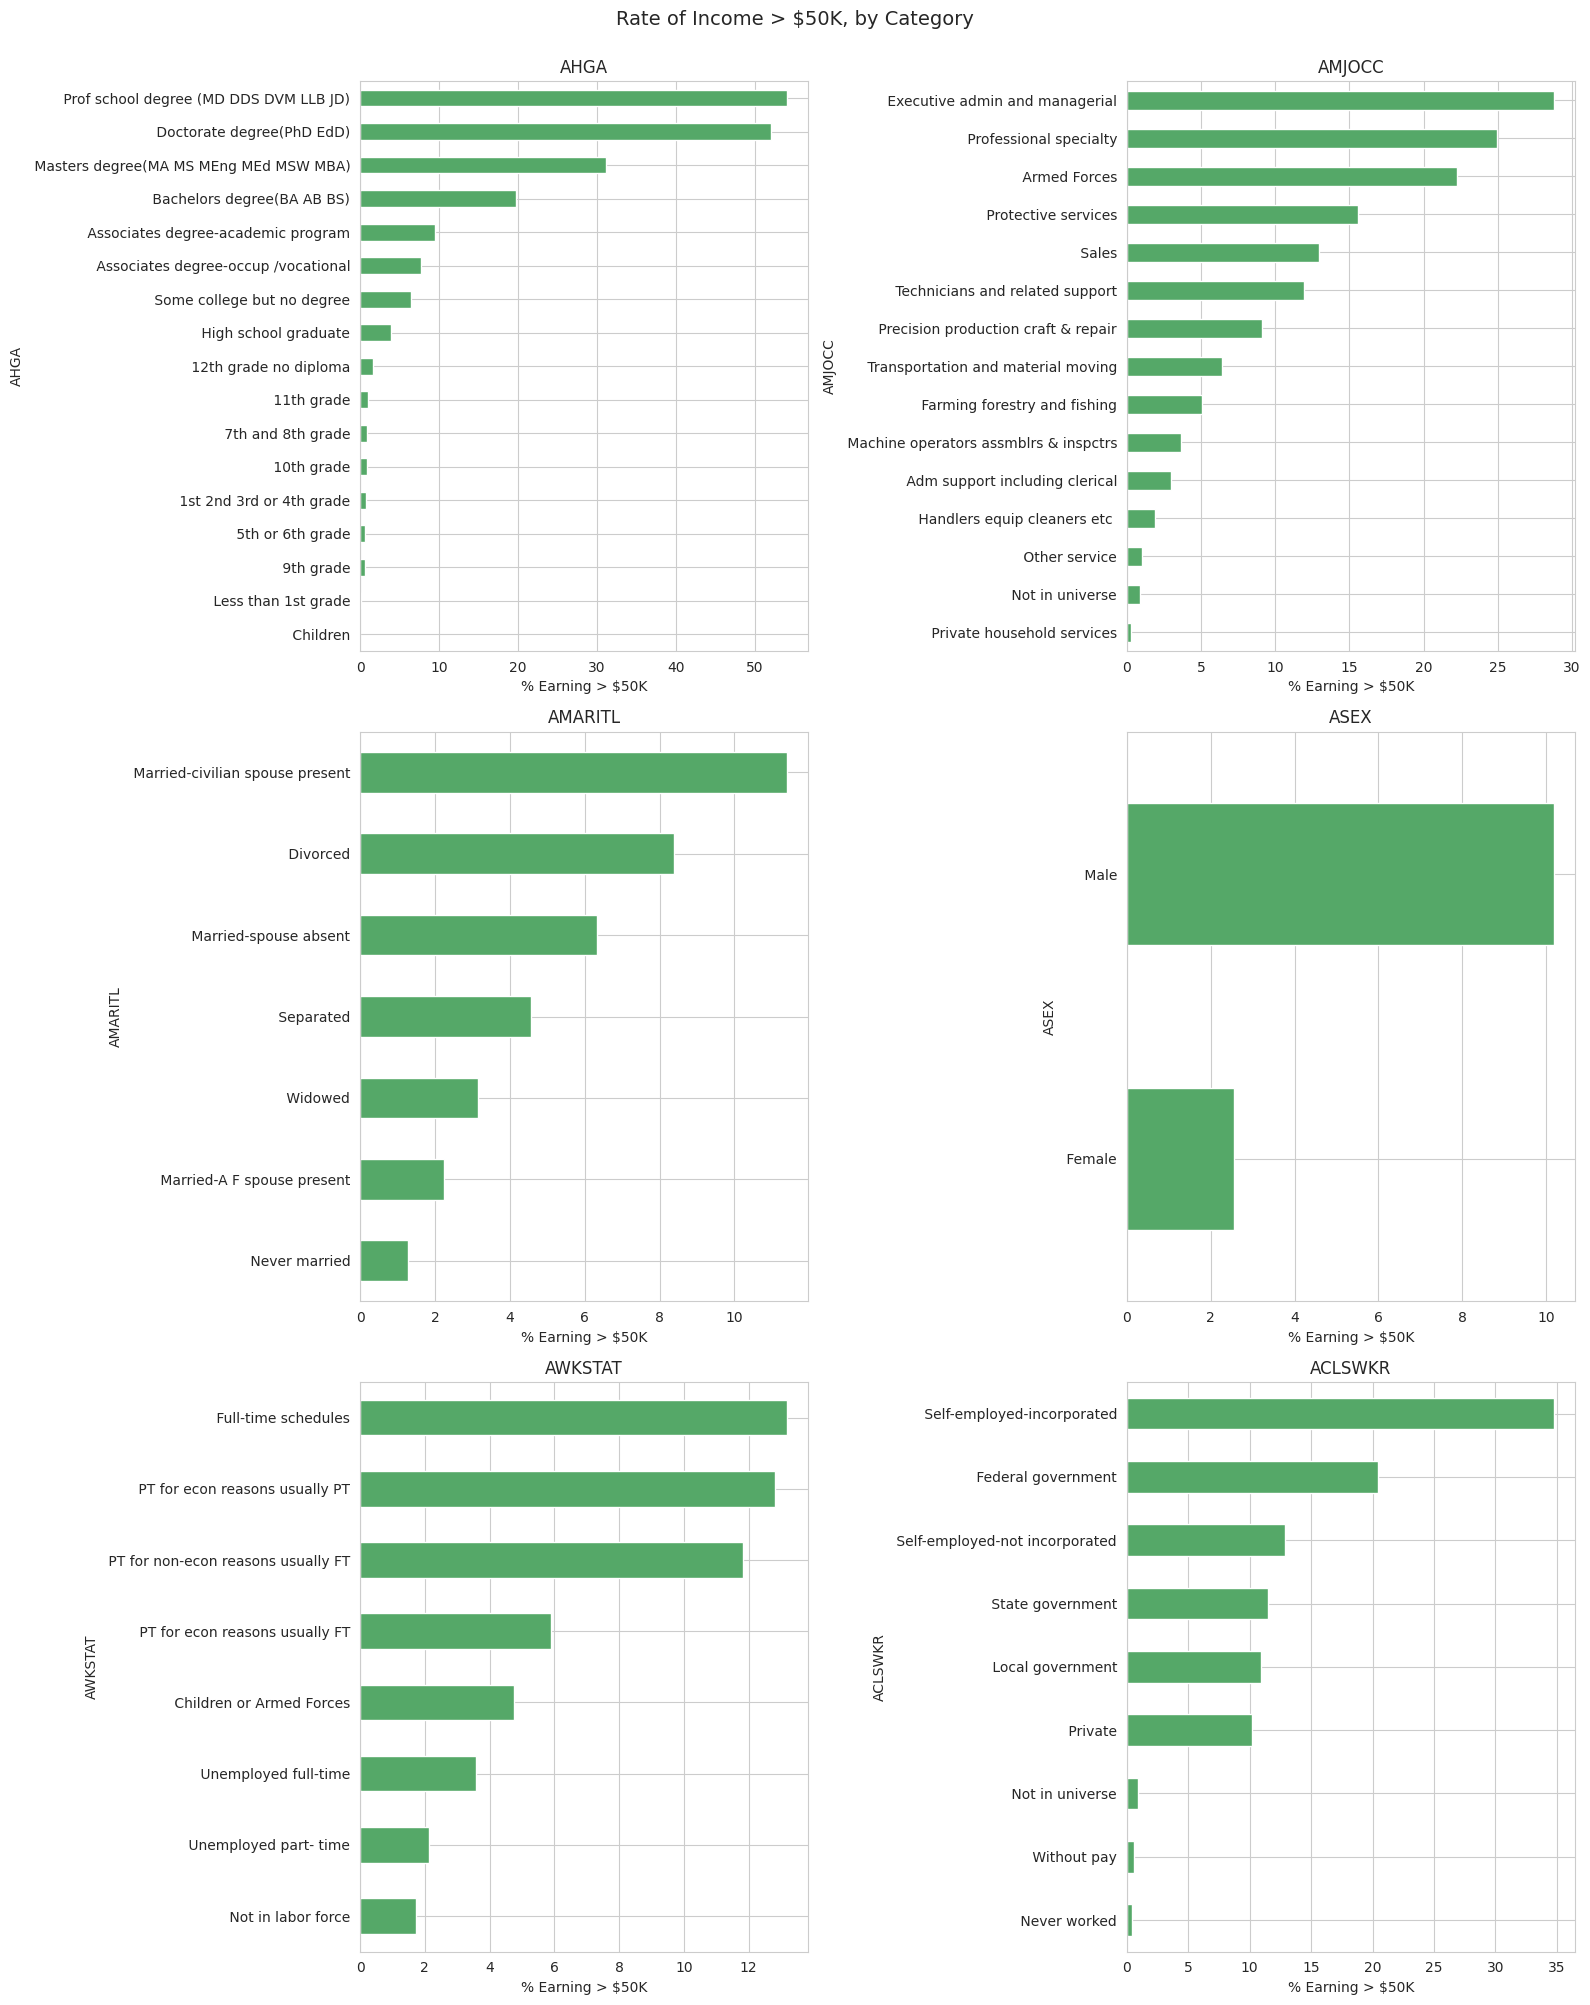

In [ ]:
key_categorical_cols = ["AHGA", "AMJOCC", "AMARITL", "ASEX", "AWKSTAT", "ACLSWKR"]

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, col in zip(axes, key_categorical_cols):
    rate_by_cat = (
        df_clean.groupby(col)[TARGET_COL]
        .apply(lambda s: (s == " 50000+.").mean() * 100)
        .sort_values(ascending=False)
    )
    rate_by_cat.plot(kind="barh", ax=ax, color="#55A868")
    ax.set_xlabel("% Earning > $50K")
    ax.set_title(col)
    ax.invert_yaxis()

plt.suptitle("Rate of Income > $50K, by Category", fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

In [ ]:
# Raw numbers behind the categorical-vs-target bar charts - income rate,
# with counts, per category, for each key column
for col in key_categorical_cols:
    print(f"=== {col} ===")
    summary = df_clean.groupby(col)[TARGET_COL].agg(
        n="count",
        pct_above_50k=lambda s: round((s == " 50000+.").mean() * 100, 2)
    ).sort_values("pct_above_50k", ascending=False)
    print(summary)
    print()

=== AHGA ===
                                            n  pct_above_50k
AHGA                                                        
Prof school degree (MD DDS DVM LLB JD)   1793          54.04
Doctorate degree(PhD EdD)                1263          52.02
Masters degree(MA MS MEng MEd MSW MBA)   6541          31.16
Bachelors degree(BA AB BS)              19865          19.71
Associates degree-academic program       4363           9.44
Associates degree-occup /vocational      5358           7.71
Some college but no degree              27820           6.42
High school graduate                    48407           3.88
12th grade no diploma                    2126           1.60
11th grade                               6876           1.02
7th and 8th grade                        8007           0.90
10th grade                               7557           0.82
1st 2nd 3rd or 4th grade                 1799           0.72
5th or 6th grade                         3277           0.67
9th grade  

In [ ]:
# Country-of-birth distributions - check the "dominated by one majority
# category" assumption directly, top 10 + how much the top category covers
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    counts = df_clean[col].value_counts()
    top_pct = counts.iloc[0] / counts.sum() * 100
    print(f"=== {col} ===")
    print(f"Top category covers {top_pct:.2f}% of rows")
    print(counts.head(10))
    print(f"... ({len(counts)} total categories)")
    print()

=== PENATVTY ===
Top category covers 88.71% of rows
PENATVTY
 United-States         176989
 Mexico                  5767
Missing                  3393
 Puerto-Rico             1400
 Germany                  851
 Philippines              845
 Cuba                     837
 Canada                   700
 Dominican-Republic       690
 El-Salvador              689
Name: count, dtype: int64
... (43 total categories)

=== PEMNTVTY ===
Top category covers 80.43% of rows
PEMNTVTY
 United-States    160479
 Mexico             9781
Missing             6119
 Puerto-Rico        2473
 Italy              1844
 Canada             1451
 Germany            1382
 Philippines        1231
 Poland             1110
 El-Salvador        1108
Name: count, dtype: int64
... (43 total categories)

=== PEFNTVTY ===
Top category covers 79.77% of rows
PEFNTVTY
 United-States         159163
 Mexico                 10008
Missing                  6713
 Puerto-Rico             2680
 Italy                   2212
 Canada    

In [ ]:
# Detailed vs. major code redundancy check - does the major code collapse
# cleanly from the detailed code, or is there real independent information?
print("Unique ADTINK values per AMJIND category (industry):")
print(df_clean.groupby("AMJIND")["ADTINK"].nunique().sort_values(ascending=False))
print()
print("Unique ADTOCC values per AMJOCC category (occupation):")
print(df_clean.groupby("AMJOCC")["ADTOCC"].nunique().sort_values(ascending=False))

Unique ADTINK values per AMJIND category (industry):
AMJIND
Manufacturing-durable goods            14
Manufacturing-nondurable goods         10
Public administration                   4
Agriculture                             2
Finance insurance and real estate       2
Business and repair services            2
Communications                          1
Armed Forces                            1
Entertainment                           1
Education                               1
Construction                            1
Hospital services                       1
Medical except hospital                 1
Mining                                  1
Not in universe or children             1
Forestry and fisheries                  1
Other professional services             1
Personal services except private HH     1
Private household services              1
Retail trade                            1
Social services                         1
Transportation                          1
Utilities and sa

In [ ]:
# Cardinality check across ALL categorical columns - flags which ones will
# need grouping/encoding care in Section 5 (e.g. one-hot encoding a 50+
# level column directly would explode the feature space)
cardinality = df_clean[CATEGORICAL_COLS].nunique().sort_values(ascending=False)
print("Categorical column cardinality (number of unique levels):")
cardinality

Categorical column cardinality (number of unique levels):


ADTINK      52
GRINST      51
ADTOCC      47
PENATVTY    43
PEMNTVTY    43
PEFNTVTY    43
HHDFMX      38
AMJIND      24
AHGA        17
AMJOCC      15
AREORGN     10
MIGMTR1     10
MIGMTR4     10
ACLSWKR      9
MIGMTR3      9
HHDREL       8
AWKSTAT      8
AMARITL      7
AUNTYPE      6
GRINREG      6
FILESTAT     6
PARENT       5
PRCITSHP     5
ARACE        5
MIGSUN       4
SEOTR        3
AUNMEM       3
AHSCOL       3
MIGSAME      3
VETYN        3
VETQVA       3
ASEX         2
year         2
dtype: int64

---

## 4. Feature Engineering & Dataset Splitting

In [ ]:
# --- Deterministic feature engineering (safe pre-split) ---
df_fe = df_clean.copy()

# Drop the redundant detailed-code columns, keeping the major-code versions
# (ADTINK collapses cleanly into AMJIND for 18/24 categories;
# ADTOCC collapses less cleanly into AMJOCC but still cuts cardinality 47 -> 15)
df_fe = df_fe.drop(columns=["ADTINK", "ADTOCC"])

# Hourly-worker indicator, given AHRSPAY's diluted correlation (0.025) -
# it's only meaningfully populated for hourly workers, 0 otherwise
df_fe["hourly_worker"] = (df_fe["AHRSPAY"] > 0).astype(int)

# Purely cosmetic: relabel "Missing" -> "Unknown" specifically in the country
# columns, so it reads as "birth country unknown" rather than a literal
# country name in later charts/importance tables. No effect on modeling -
# it's still just one more category either way, and this is deterministic
# (no distribution info used), so it's safe to do before the split.
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    df_fe[col] = df_fe[col].replace("Missing", "Unknown")

print(f"df_fe shape after dropping detailed codes + adding indicator: {df_fe.shape}")
print()
print("Confirming relabel applied:")
for col in ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]:
    print(f"  {col}: 'Missing' count = {(df_fe[col] == 'Missing').sum()}, 'Unknown' count = {(df_fe[col] == 'Unknown').sum()}")
print()
df_fe[["AMJIND", "AMJOCC", "AHRSPAY", "hourly_worker"]].head(10)

df_fe shape after dropping detailed codes + adding indicator: (199523, 40)

Confirming relabel applied:
  PENATVTY: 'Missing' count = 0, 'Unknown' count = 3393
  PEMNTVTY: 'Missing' count = 0, 'Unknown' count = 6119
  PEFNTVTY: 'Missing' count = 0, 'Unknown' count = 6713



,AMJIND,AMJOCC,AHRSPAY,hourly_worker
0,Not in universe or children,Not in universe,0,0
1,Construction,Precision production craft & repair,0,0
2,Not in universe or children,Not in universe,0,0
3,Not in universe or children,Not in universe,0,0
4,Not in universe or children,Not in universe,0,0
5,Entertainment,Professional specialty,1200,1
6,Finance insurance and real estate,Executive admin and managerial,0,0
7,Construction,Handlers equip cleaners etc,0,0
8,Education,Adm support including clerical,876,1
9,Construction,Machine operators assmblrs & inspctrs,0,0


In [ ]:
# Update the working column lists to reflect the drops/additions
NUMERIC_COLS = ["AAGE", "CAPGAIN", "GAPLOSS", "DIVVAL", "NOEMP", "WKSWORK", "AHRSPAY", "hourly_worker"]
CATEGORICAL_COLS = [c for c in df_fe.columns if c not in NUMERIC_COLS + [TARGET_COL]]

print(f"Numeric columns ({len(NUMERIC_COLS)}): {NUMERIC_COLS}")
print(f"Categorical columns ({len(CATEGORICAL_COLS)}): {len(CATEGORICAL_COLS)} total")

Numeric columns (8): ['AAGE', 'CAPGAIN', 'GAPLOSS', 'DIVVAL', 'NOEMP', 'WKSWORK', 'AHRSPAY', 'hourly_worker']
Categorical columns (31): 31 total


### Dataset Splitting

80/20 stratified split on `income`, matching the stratification approach used
throughout - with a target this imbalanced (93.79%/6.21%), an unstratified
split risks the minority class landing at meaningfully different rates in
train vs. test purely by chance.

In [ ]:
X = df_fe.drop(columns=[TARGET_COL])
y = (df_fe[TARGET_COL] == " 50000+.").astype(int)  # 1 = income > $50K, the real encoding used from here on

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print()
print("Train class balance:")
print(y_train.value_counts(normalize=True).round(4) * 100)
print()
print("Test class balance:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training rows: 159618
Testing rows: 39905

Train class balance:
income
0    93.79
1     6.21
Name: proportion, dtype: float64

Test class balance:
income
0    93.8
1     6.2
Name: proportion, dtype: float64


### Collapsing High-Cardinality Country Columns - Fit on Training Set Only

Top-N countries determined from `X_train` only, then applied identically to
`X_test`. Any country appearing in `X_test` that wasn't among the training
set's top N (including any not seen in training at all) is mapped to
`"Other"`, the same way a genuinely unseen category would be handled at
prediction time in production.

In [ ]:
country_cols = ["PENATVTY", "PEMNTVTY", "PEFNTVTY"]
TOP_N_COUNTRIES = 9  # matches the top-9 shown in Section 3.5's value_counts head

def fit_top_n_categories(train_series: pd.Series, n: int) -> list:
    # "Fitting" here just means reading off the N most frequent categories
    # from the training data - analogous to fitting an imputer/scaler, this
    # must only ever look at X_train
    return train_series.value_counts().head(n).index.tolist()

def apply_top_n_collapse(series: pd.Series, top_categories: list) -> pd.Series:
    # Any category not in the fitted top-N list (whether it's a rare country
    # seen in training, or one that only appears in test) becomes "Other"
    return series.where(series.isin(top_categories), other="Other")

top_country_lookup = {}
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

for col in country_cols:
    top_categories = fit_top_n_categories(X_train[col], TOP_N_COUNTRIES)
    top_country_lookup[col] = top_categories

    # Apply the SAME fitted top-N list to both train and test - test is
    # never used to decide which countries "count," only to be transformed
    X_train_fe[col] = apply_top_n_collapse(X_train[col], top_categories)
    X_test_fe[col] = apply_top_n_collapse(X_test[col], top_categories)

    print(f"{col}: {X_train[col].nunique()} -> {X_train_fe[col].nunique()} categories (train)")

print()
print("Example fitted top categories (PENATVTY):", top_country_lookup["PENATVTY"])

PENATVTY: 43 -> 10 categories (train)
PEMNTVTY: 43 -> 10 categories (train)
PEFNTVTY: 43 -> 10 categories (train)

Example fitted top categories (PENATVTY): [' United-States', ' Mexico', 'Unknown', ' Puerto-Rico', ' Germany', ' Cuba', ' Philippines', ' Dominican-Republic', ' Canada']


In [ ]:
# Sanity check: confirm no leakage - every category in the collapsed test
# set should already exist in the collapsed training set (since anything
# else was mapped to "Other", which itself is guaranteed to exist in train)
for col in country_cols:
    unseen_in_test = set(X_test_fe[col].unique()) - set(X_train_fe[col].unique())
    print(f"{col}: categories in test not present in train (post-collapse): {unseen_in_test}")

PENATVTY: categories in test not present in train (post-collapse): set()
PEMNTVTY: categories in test not present in train (post-collapse): set()
PEFNTVTY: categories in test not present in train (post-collapse): set()


### One-Hot Encoding - Fit on Training Set Only

In [ ]:
# drop_first=True avoids the classic dummy-variable trap (perfect
# multicollinearity between a category's dummy columns), which matters for
# any model that isn't purely tree-based - kept as a consistent default here
X_train_encoded = pd.get_dummies(X_train_fe, columns=CATEGORICAL_COLS, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_fe, columns=CATEGORICAL_COLS, drop_first=True)

# Align test columns to train columns exactly - any column present in train
# but missing in test (a category that simply didn't occur in the test rows)
# is filled with 0; any column that only appeared in test is dropped, since
# the model was never trained on it and couldn't use it anyway
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(f"X_train_encoded shape: {X_train_encoded.shape}")
print(f"X_test_encoded shape:  {X_test_encoded.shape}")
assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Column mismatch between train/test!"
print("Column alignment confirmed.")

X_train_encoded shape: (159618, 282)
X_test_encoded shape:  (39905, 282)
Column alignment confirmed.


In [ ]:
# XGBoost rejects feature names containing [, ], or < - pd.get_dummies can
# produce these when a category value itself contains them (here: HHDFMX's
# "<18" age-bracket categories). Fix: rewrite "<18" -> "under18" (readable,
# preserves meaning) rather than a bare symbol swap, applied identically to
# train and test so they stay aligned. Random Forest/Bayesian are unaffected
# either way (sklearn has no such restriction) - this only matters for XGBoost.
import re

def sanitize_feature_names(columns):
    cleaned = []
    for col in columns:
        col = re.sub(r"<(\d+)", r"under\1", str(col))  # e.g. "<18" -> "under18"
        col = re.sub(r"[\[\]]", "", col)                # strip any remaining brackets
        cleaned.append(col)
    return cleaned

bad_cols = [c for c in X_train_encoded.columns if re.search(r"[\[\]<]", str(c))]
print(f"Columns with invalid characters found: {len(bad_cols)}")
print(bad_cols)

X_train_encoded.columns = sanitize_feature_names(X_train_encoded.columns)
X_test_encoded.columns = sanitize_feature_names(X_test_encoded.columns)

assert list(X_train_encoded.columns) == list(X_test_encoded.columns), "Column mismatch after sanitizing!"
print("Column alignment confirmed after sanitizing.")
print()
print("Example renamed columns:")
print([c for c in X_train_encoded.columns if "under18" in c][:5])

Columns with invalid characters found: 15
['HHDFMX_ Child <18 ever marr RP of subfamily', 'HHDFMX_ Child <18 ever marr not in subfamily', 'HHDFMX_ Child <18 never marr RP of subfamily', 'HHDFMX_ Child <18 never marr not in subfamily', 'HHDFMX_ Child <18 spouse of subfamily RP', 'HHDFMX_ Grandchild <18 ever marr not in subfamily', 'HHDFMX_ Grandchild <18 never marr RP of subfamily', 'HHDFMX_ Grandchild <18 never marr child of subfamily RP', 'HHDFMX_ Grandchild <18 never marr not in subfamily', 'HHDFMX_ Other Rel <18 ever marr RP of subfamily', 'HHDFMX_ Other Rel <18 ever marr not in subfamily', 'HHDFMX_ Other Rel <18 never marr child of subfamily RP', 'HHDFMX_ Other Rel <18 never marr not in subfamily', 'HHDFMX_ Other Rel <18 never married RP of subfamily', 'HHDFMX_ Other Rel <18 spouse of subfamily RP']
Column alignment confirmed after sanitizing.

Example renamed columns:
['HHDFMX_ Child under18 ever marr RP of subfamily', 'HHDFMX_ Child under18 ever marr not in subfamily', 'HHDFMX_ C

In [ ]:
print("Final training feature set:", X_train_encoded.shape)
print("Final test feature set:", X_test_encoded.shape)

Final training feature set: (159618, 282)
Final test feature set: (39905, 282)


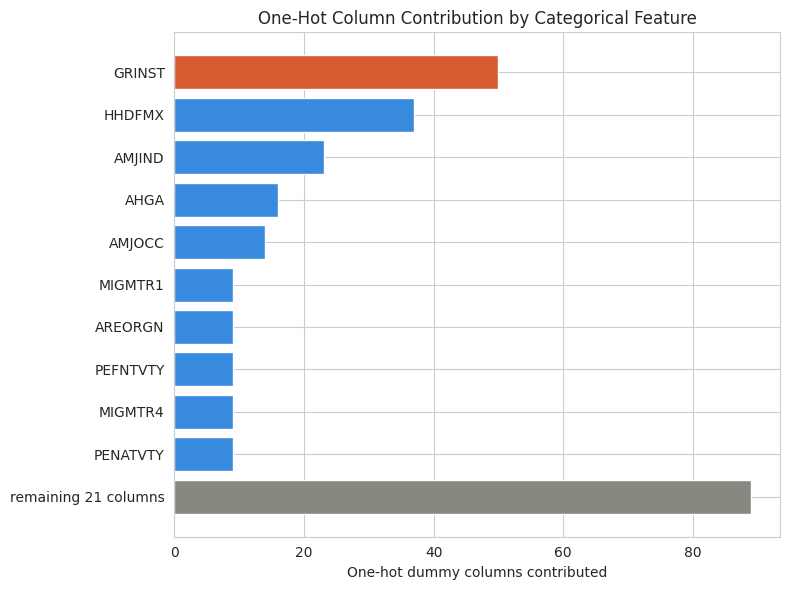

Total encoded features: 282 (8 numeric + 274 one-hot dummy columns)
GRINST alone contributes 50 columns - the largest single contributor, more than all three collapsed country columns combined.


In [ ]:
# Which categorical columns contribute the most one-hot columns? Computed
# directly from X_train_encoded so this stays accurate if anything upstream
# changes. See Section 4 Summary below for why GRINST is called out.
dummy_counts = pd.Series({
    col: sum(c.startswith(f"{col}_") for c in X_train_encoded.columns)
    for col in CATEGORICAL_COLS
}).sort_values(ascending=False)

top_n = 10
plot_data = pd.concat([
    dummy_counts.head(top_n),
    pd.Series({f"remaining {len(dummy_counts) - top_n} columns": dummy_counts.iloc[top_n:].sum()})
])

colors = [
    "#D85A30" if col == "GRINST" else
    "#888780" if "remaining" in col else
    "#378ADD"
    for col in plot_data.index
]

plt.figure(figsize=(8, 6))
plt.barh(plot_data.index[::-1], plot_data.values[::-1], color=colors[::-1])
plt.xlabel("One-hot dummy columns contributed")
plt.title("One-Hot Column Contribution by Categorical Feature")
plt.tight_layout()
plt.show()

print(f"Total encoded features: {X_train_encoded.shape[1]} "
      f"({len(NUMERIC_COLS)} numeric + {dummy_counts.sum()} one-hot dummy columns)")
print(f"GRINST alone contributes {dummy_counts['GRINST']} columns - "
      f"the largest single contributor, more than all three collapsed country columns combined.")

---

## 5. Decision Tree Classifier

The simplest of the three models

Hyperparameters (`max_depth`, `min_samples_leaf`, `min_samples_split`) are
tuned via `RandomizedSearchCV` on a 25,000-row stratified subsample (for
speed), scored on F1

In [ ]:
results = {}

def evaluate_model(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    auc = roc_auc_score(y_te, y_proba)
    ap = average_precision_score(y_te, y_proba)

    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1,
                      'roc_auc': auc, 'avg_precision': ap}

    print(f'--- {name} ---')
    print(f'Accuracy      : {acc:.4f}')
    print(f'Precision     : {prec:.4f}')
    print(f'Recall        : {rec:.4f}')
    print(f'F1 score      : {f1:.4f}')
    print(f'ROC AUC       : {auc:.4f}')
    print(f'Avg Precision : {ap:.4f}  (area under precision-recall curve)')
    print()
    print(classification_report(y_te, y_pred, target_names=['<=50K','>50K']))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
    ConfusionMatrixDisplay.from_predictions(y_te, y_pred, display_labels=['<=50K','>50K'],
                                             cmap='Blues', ax=axes[0])
    axes[0].set_title(f'{name} - Confusion Matrix')

    fpr, tpr, _ = roc_curve(y_te, y_proba)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'{name} - ROC Curve')
    axes[1].legend()

    prec_curve, rec_curve, _ = precision_recall_curve(y_te, y_proba)
    axes[2].plot(rec_curve, prec_curve, label=f'AP = {ap:.3f}')
    axes[2].axhline(y_te.mean(), color='k', linestyle='--', alpha=0.4, label='baseline (prevalence)')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].set_title(f'{name} - Precision-Recall Curve')
    axes[2].legend()

    plt.tight_layout()
    safe_name = name.lower().replace(' ', '_')
    plt.show()
    return y_pred, y_proba


In [ ]:
# Draw a stratified 25,000-row subsample of the training data for hyperparameter search.
SUBSAMPLE_SIZE = 25000
X_train_sub, _, y_train_sub, _ = train_test_split(
    X_train_encoded, y_train, train_size=SUBSAMPLE_SIZE, random_state=RANDOM_STATE, stratify=y_train
)
print('Subsample for hyperparameter search:', X_train_sub.shape)
print('Subsample class balance:\\n', y_train_sub.value_counts(normalize=True).round(4))
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)



Subsample for hyperparameter search: (25000, 282)
Subsample class balance:\n income
0    0.9379
1    0.0621
Name: proportion, dtype: float64


class weight=balanced given the severity of the imbalance

In [ ]:
#Search for best hyperpameters make best model
dt_param_dist = {
    'max_depth': randint(4, 25),
    'min_samples_leaf': randint(1, 50),
    'min_samples_split': randint(2, 50),
}

dt_base = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
dt_search = RandomizedSearchCV(dt_base, dt_param_dist, n_iter=12, scoring='f1',
                                cv=cv_strategy, random_state=RANDOM_STATE, n_jobs=1)
dt_search.fit(X_train_sub, y_train_sub)
print('Best params (from subsample search):', dt_search.best_params_)
print('Best CV F1 (subsample):', dt_search.best_score_)
best_params = dict(dt_search.best_params_)

Best params (from subsample search): {'max_depth': 18, 'min_samples_leaf': 18, 'min_samples_split': 44}
Best CV F1 (subsample): 0.3813374064054856


--- Decision Tree ---
Accuracy      : 0.8439
Precision     : 0.2645
Recall        : 0.8514
F1 score      : 0.4036
ROC AUC       : 0.9030
Avg Precision : 0.5440  (area under precision-recall curve)

              precision    recall  f1-score   support

       <=50K       0.99      0.84      0.91     37429
        >50K       0.26      0.85      0.40      2476

    accuracy                           0.84     39905
   macro avg       0.63      0.85      0.66     39905
weighted avg       0.94      0.84      0.88     39905



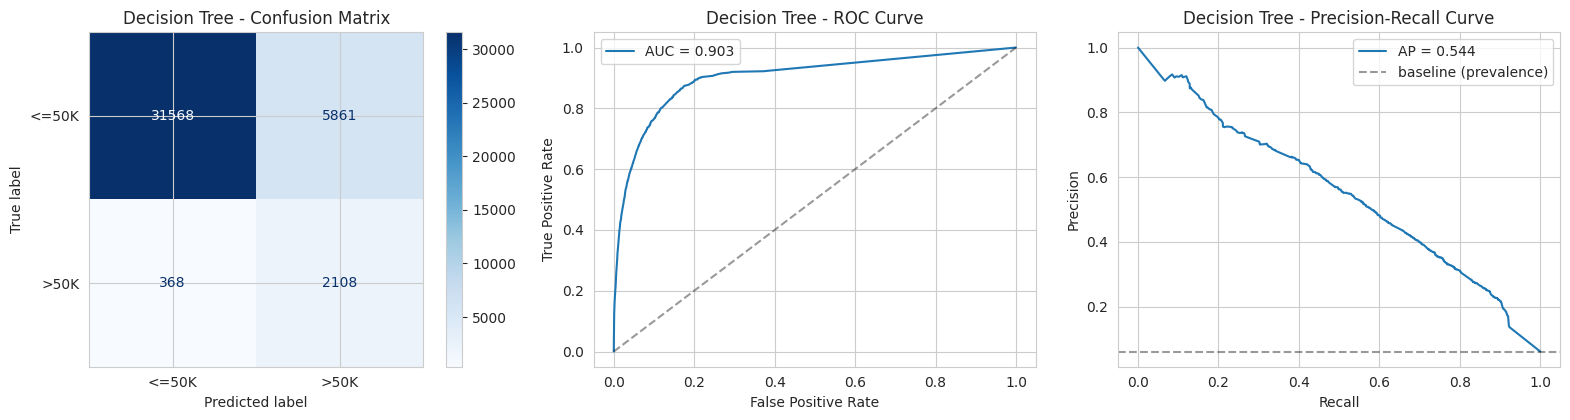

In [ ]:
# Final fit on the FULL training set with the selected hyperparameters
dt_final = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced',
                                    **best_params)
dt_final.fit(X_train_encoded, y_train)

_ = evaluate_model('Decision Tree', dt_final, X_test_encoded, y_test)


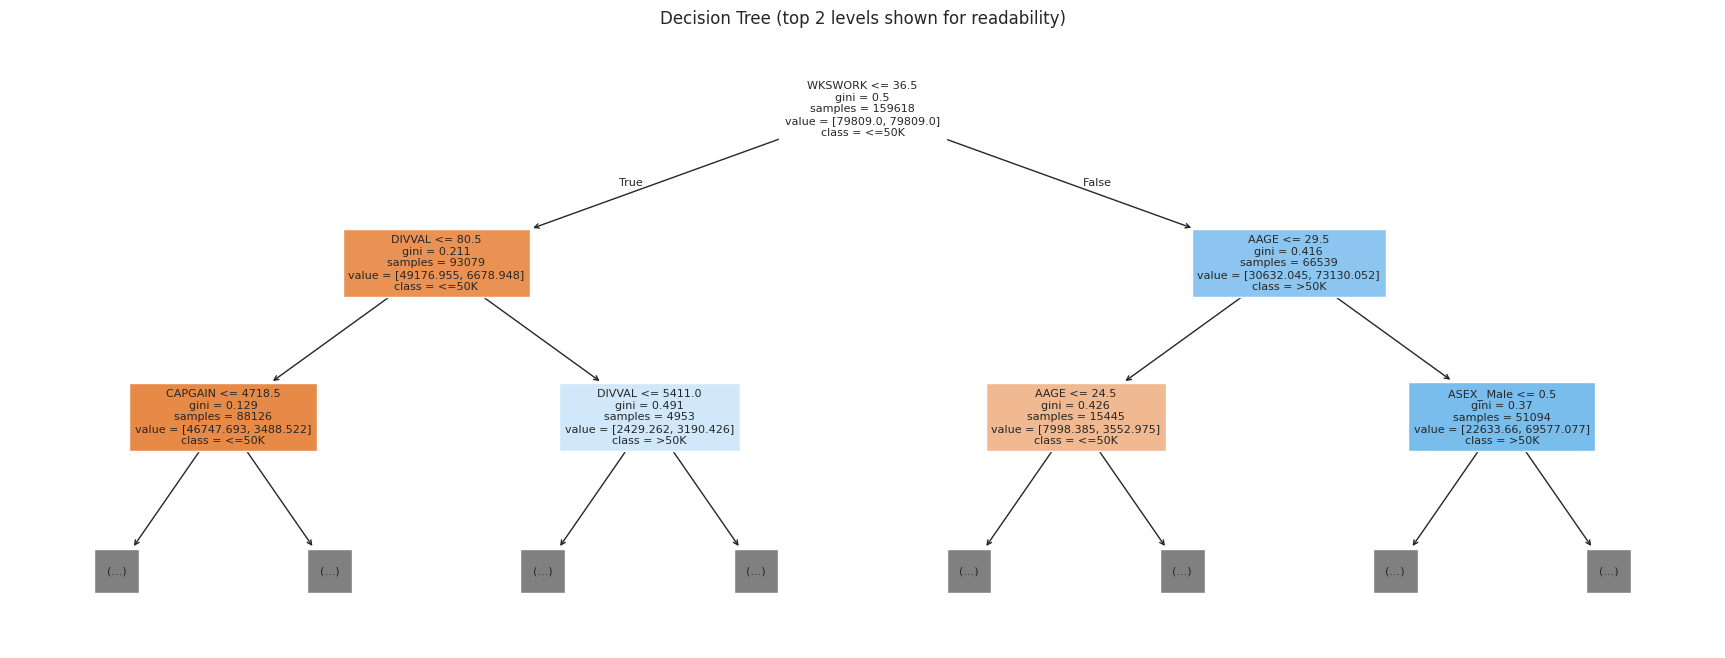

In [ ]:
plt.figure(figsize=(22, 8))
plot_tree(dt_final, max_depth=2, feature_names=X_train_encoded.columns.to_list(), class_names=['<=50K','>50K'],
          filled=True, fontsize=8)
plt.title('Decision Tree (top 2 levels shown for readability)')
plt.show()


In [ ]:
dt_importances = pd.Series(dt_final.feature_importances_, index=X_train_encoded.columns.to_list()).sort_values(ascending=False)
print(dt_importances.head(10))

WKSWORK                                   0.447769
AAGE                                      0.116290
DIVVAL                                    0.098270
ASEX_ Male                                0.058132
CAPGAIN                                   0.041961
AHGA_ High school graduate                0.036328
AMJOCC_ Executive admin and managerial    0.020738
AMJOCC_ Professional specialty            0.018799
NOEMP                                     0.017152
AHGA_ Bachelors degree(BA AB BS)          0.010650
dtype: float64


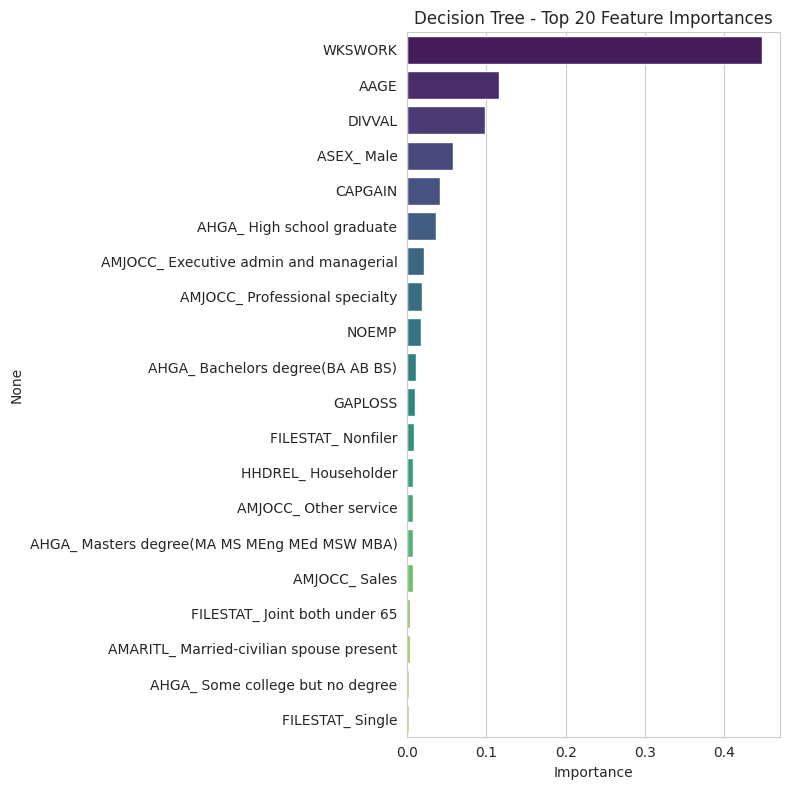

WKSWORK                                         0.447769
AAGE                                            0.116290
DIVVAL                                          0.098270
ASEX_ Male                                      0.058132
CAPGAIN                                         0.041961
AHGA_ High school graduate                      0.036328
AMJOCC_ Executive admin and managerial          0.020738
AMJOCC_ Professional specialty                  0.018799
NOEMP                                           0.017152
AHGA_ Bachelors degree(BA AB BS)                0.010650
GAPLOSS                                         0.010083
FILESTAT_ Nonfiler                              0.008900
HHDREL_ Householder                             0.007949
AMJOCC_ Other service                           0.007747
AHGA_ Masters degree(MA MS MEng MEd MSW MBA)    0.007653
AMJOCC_ Sales                                   0.007152
FILESTAT_ Joint both under 65                   0.003449
AMARITL_ Married-civilian spous

In [ ]:
dt_importances = pd.Series(dt_final.feature_importances_, index=X_train_encoded.columns.to_list()).sort_values(ascending=False)
top_n = 20
plt.figure(figsize=(8, 8))
sns.barplot(x=dt_importances.head(top_n).values, y=dt_importances.head(top_n).index,
            hue=dt_importances.head(top_n).index, palette='viridis', legend=False)
plt.title(f'Decision Tree - Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(dt_importances.head(top_n))

---

## 6. Random Forest Classifier:

Random Forest addresses the Decision Tree's core weakness by averaging many trees

In [ ]:
rf_param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': randint(10, 30),
    'min_samples_leaf': randint(1, 20),
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=1)
rf_search = RandomizedSearchCV(rf_base, rf_param_dist, n_iter=12, scoring='f1',
                                cv=cv_strategy, random_state=RANDOM_STATE, n_jobs=1)
rf_search.fit(X_train_sub, y_train_sub)
print('Best params (from subsample search):', rf_search.best_params_)
print('Best CV F1 (subsample):', rf_search.best_score_)


Best params (from subsample search): {'max_depth': 20, 'min_samples_leaf': 2, 'n_estimators': 142}
Best CV F1 (subsample): 0.4649429899749447


--- Random Forest ---
Accuracy      : 0.8603
Precision     : 0.2918
Recall        : 0.8772
F1 score      : 0.4379
ROC AUC       : 0.9416
Avg Precision : 0.5894  (area under precision-recall curve)

              precision    recall  f1-score   support

       <=50K       0.99      0.86      0.92     37429
        >50K       0.29      0.88      0.44      2476

    accuracy                           0.86     39905
   macro avg       0.64      0.87      0.68     39905
weighted avg       0.95      0.86      0.89     39905



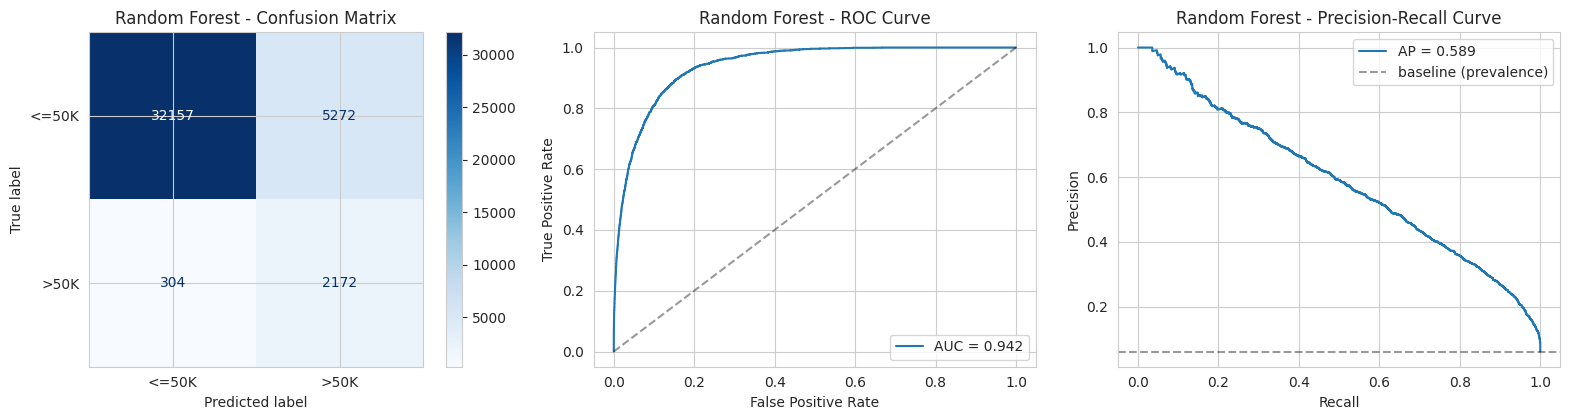

In [ ]:
rf_final = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced',
                                    n_jobs=1, **rf_search.best_params_)
rf_final.fit(X_train_encoded, y_train)

_ = evaluate_model('Random Forest', rf_final, X_test_encoded, y_test)


/tmp/ipykernel_473/831878674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(top_n).values, y=rf_importances.head(top_n).index, palette='viridis')


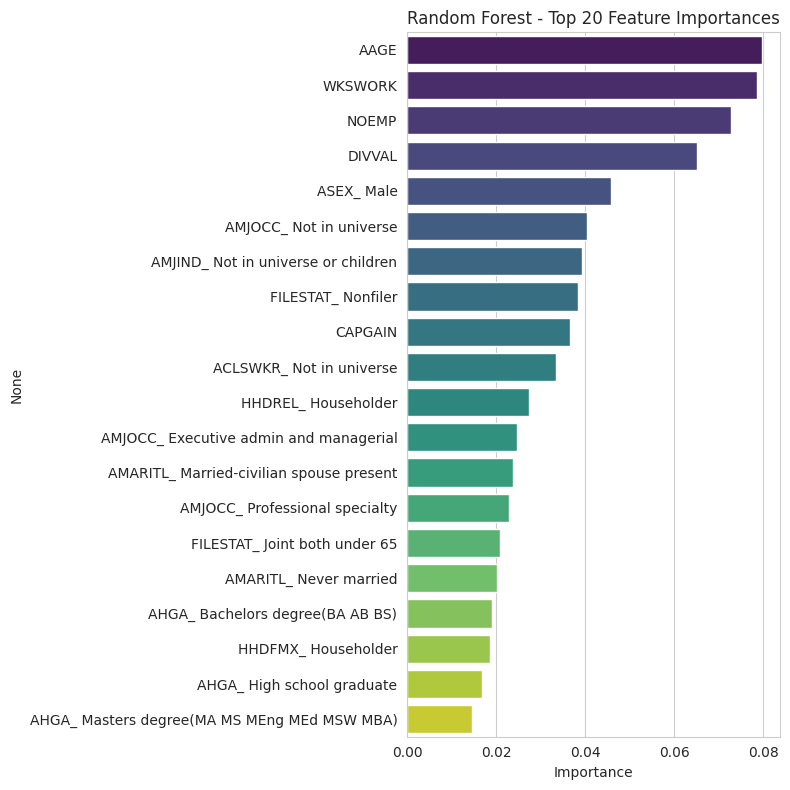

AAGE                                            0.079771
WKSWORK                                         0.078525
NOEMP                                           0.072698
DIVVAL                                          0.065197
ASEX_ Male                                      0.045846
AMJOCC_ Not in universe                         0.040461
AMJIND_ Not in universe or children             0.039371
FILESTAT_ Nonfiler                              0.038307
CAPGAIN                                         0.036603
ACLSWKR_ Not in universe                        0.033365
HHDREL_ Householder                             0.027344
AMJOCC_ Executive admin and managerial          0.024731
AMARITL_ Married-civilian spouse present        0.023804
AMJOCC_ Professional specialty                  0.022970
FILESTAT_ Joint both under 65                   0.020815
AMARITL_ Never married                          0.020251
AHGA_ Bachelors degree(BA AB BS)                0.019116
HHDFMX_ Householder            

In [ ]:
rf_importances = pd.Series(rf_final.feature_importances_, index=X_train_encoded.columns.to_list()).sort_values(ascending=False)
top_n = 20
plt.figure(figsize=(8, 8))
sns.barplot(x=rf_importances.head(top_n).values, y=rf_importances.head(top_n).index, palette='viridis')
plt.title(f'Random Forest - Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(rf_importances.head(top_n))


outperforms the single Decision Tree
via variance reduction from bagging + random feature subsets

---

## 7. XGBoost Classifier:
- Build an XGBoost classifier. Determine the number of trees via both a CV
  sweep and early stopping, rather than guessing a fixed count.
- Given the severity of the class imbalance confirmed in Section 1
  (93.79%/6.21%) - considerably more extreme than a typical classification
  dataset - `scale_pos_weight` is built into the hyperparameter search
  directly here, rather than deferred to a later "fix" section. Plain
  accuracy is not a reliable metric on its own; precision/recall/F1/AUC on
  the minority (`income > $50K`) class are reported alongside it throughout.
- Assess performance, identify the most important features, and check
  whether more training data would help via a learning curve.

Feature names used throughout this section are the sanitized versions from
Section 4 (`<18` -> `under18`) - required for XGBoost specifically, since it
rejects `[`, `]`, `<` in column names at fit time (Random Forest/Bayesian
have no such restriction).

### Determining the Number of Trees

XGBoost's trees are built sequentially, each one correcting the errors of the
existing ensemble - unlike a bagged model, more trees does not "safely"
plateau, it can actively start overfitting past a certain point. The number
of trees is determined two ways:
1. A CV sweep across fixed tree counts, to see the shape of that overfitting
   risk directly on this dataset, scored on F1 (not accuracy) since accuracy
   is uninformative on a 93.79%/6.21% target.
2. **Early stopping** - a validation split is carved out of the training set,
   and the model stops adding trees once validation performance stops
   improving, rather than guessing a single fixed count in advance.

scale_pos_weight (neg/pos ratio in training data): 15.113

n_estimators=50: mean CV F1 (minority class) = 0.4069 (+/- 0.0022)
n_estimators=100: mean CV F1 (minority class) = 0.4373 (+/- 0.0033)
n_estimators=200: mean CV F1 (minority class) = 0.4553 (+/- 0.0018)
n_estimators=300: mean CV F1 (minority class) = 0.4647 (+/- 0.0021)
n_estimators=500: mean CV F1 (minority class) = 0.4757 (+/- 0.0026)


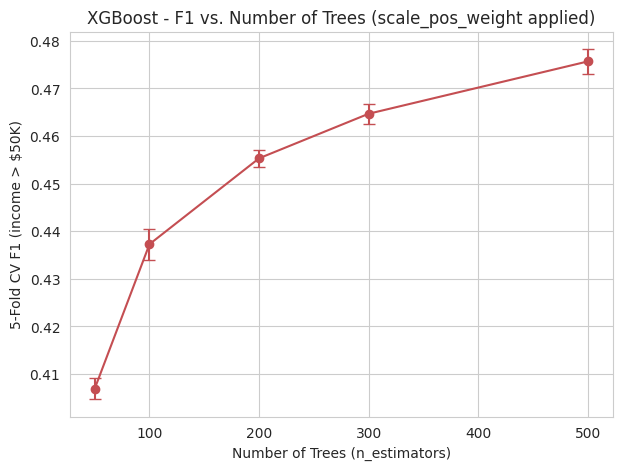

In [ ]:
# CV sweep across fixed tree counts, holding other hyperparameters constant.
# scale_pos_weight is included here too (not left at default) - leaving it
# unset during this sweep would optimize purely for accuracy on a target
# that's 93.79% one class, which tells us very little about real performance.
# n_jobs is capped (not -1) to avoid oversubscribing CPU/memory across the
# 25 fits this loop performs (5 tree counts x 5 CV folds each).
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight_value = neg_count / pos_count
print(f"scale_pos_weight (neg/pos ratio in training data): {scale_pos_weight_value:.3f}")
print()

tree_counts_xgb = [50, 100, 200, 300, 500]
xgb_cv_means, xgb_cv_stds = [], []

for n in tree_counts_xgb:
    xgb_temp = XGBClassifier(
        n_estimators=n, max_depth=4, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight_value,
        eval_metric="logloss", random_state=RANDOM_STATE,
        n_jobs=2
    )
    scores = cross_val_score(xgb_temp, X_train_encoded, y_train, cv=5, scoring="f1")
    xgb_cv_means.append(scores.mean())
    xgb_cv_stds.append(scores.std())
    print(f"n_estimators={n}: mean CV F1 (minority class) = {scores.mean():.4f} (+/- {scores.std():.4f})")

plt.figure(figsize=(7, 5))
plt.errorbar(tree_counts_xgb, xgb_cv_means, yerr=xgb_cv_stds, marker="o", capsize=4, color="#C44E52")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("5-Fold CV F1 (income > $50K)")
plt.title("XGBoost - F1 vs. Number of Trees (scale_pos_weight applied)")
plt.show()

**Result:** F1 rose steadily but with shrinking gains - 0.4069 (50 trees),
0.4373 (100), 0.4553 (200), 0.4647 (300), 0.4757 (500). Gains per step:
+0.030, +0.018, +0.009, +0.011 - a diminishing-returns pattern, not a hard
plateau, but a clear sign the useful range is captured within this sweep.

In [ ]:
# Early stopping: carve a small validation split out of the training set only
# (X_test_encoded / y_test is still never touched here)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train_encoded, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

xgb_early = XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight_value,
    eval_metric="logloss",
    early_stopping_rounds=20,
    random_state=RANDOM_STATE,
    n_jobs=2
)
xgb_early.fit(X_tr2, y_tr2, eval_set=[(X_val, y_val)], verbose=False)

print("Number of trees actually used (best_iteration):", xgb_early.best_iteration)

Number of trees actually used (best_iteration): 498


### Note on Early Stopping vs. F1

Early stopping (tracking `logloss`) did not converge within a 500-tree
ceiling, landing at **498/500** - re-tested at a 1500-tree ceiling, it landed
at **1499/1500**, i.e. it still hadn't converged. This is not a sign the
model needs thousands of trees; `logloss` can keep improving marginally in a
way that doesn't reflect any real change in classification decisions, while
the CV sweep above (scored on F1, the metric that actually matters here)
already showed clearly shrinking gains well before 500 trees. Rather than
continuing to chase logloss convergence at ever-higher ceilings,
`n_estimators` for the search below is set directly from the F1 sweep's
evidence instead of early stopping's raw tree count.

In [ ]:
# n_estimators candidates set from the F1 sweep's evidence (shrinking gains,
# largest tested value = 500) rather than early stopping's logloss-driven
# count, which did not converge at either a 500- or 1500-tree ceiling.
xgb_n_estimators_candidates = [300, 500]
print("n_estimators candidates for search:", xgb_n_estimators_candidates)

n_estimators candidates for search: [300, 500]


### Hyperparameter Search

`RandomizedSearchCV` is used in place of an exhaustive `GridSearchCV` -
the full grid below represents 72 combinations x 5 folds = 360 individual
fits, which proved too memory-intensive to run reliably in this environment
(caused a WSL crash under `GridSearchCV` with `n_jobs=-1` in multiple
places, from nested parallelism and total fit volume). `RandomizedSearchCV`
instead samples 15 of the 72 combinations across 3 folds (45 fits total),
with `n_jobs` capped rather than left at `-1` to keep memory use bounded.
`scale_pos_weight` is set once, from the training data's own class ratio,
consistent with the imbalance-handling approach used throughout this section.

In [ ]:
xgb_param_grid = {
    "n_estimators": xgb_n_estimators_candidates,
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.1, 0.2],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

xgb_grid = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight_value,
        eval_metric="logloss",
        random_state=RANDOM_STATE
        # n_jobs intentionally omitted here - defaults to 1 per fit
    ),
    xgb_param_grid,
    n_iter=15,
    cv=3,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=2,   # parallelism capped, not -1, to avoid oversubscribing memory
    verbose=2
)
xgb_grid.fit(X_train_encoded, y_train)

print("Best parameters:", xgb_grid.best_params_)
print("Best CV F1 (income > $50K):", xgb_grid.best_score_)

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
Best CV F1 (income > $50K): 0.5060164004931044


**Result:** `{'subsample': 1.0, 'n_estimators': 500, 'max_depth': 5,
'learning_rate': 0.2, 'colsample_bytree': 0.8}`, CV F1 = **0.506** - a real
improvement over the fixed-hyperparameter sweep's best (0.4757), since
`max_depth`/`learning_rate` were allowed to move jointly rather than staying
fixed. `max_depth` and `learning_rate` both landed at the edge of their
searched ranges, suggesting the true optimum may sit slightly beyond what
was searched here - noted honestly rather than treated as a hard ceiling,
though not chased further given the memory constraints already encountered.

--- XGBoost ---
Accuracy      : 0.8960
Precision     : 0.3581
Recall        : 0.8530
F1 score      : 0.5045
ROC AUC       : 0.9495
Avg Precision : 0.6642  (area under precision-recall curve)

              precision    recall  f1-score   support

       <=50K       0.99      0.90      0.94     37429
        >50K       0.36      0.85      0.50      2476

    accuracy                           0.90     39905
   macro avg       0.67      0.88      0.72     39905
weighted avg       0.95      0.90      0.91     39905



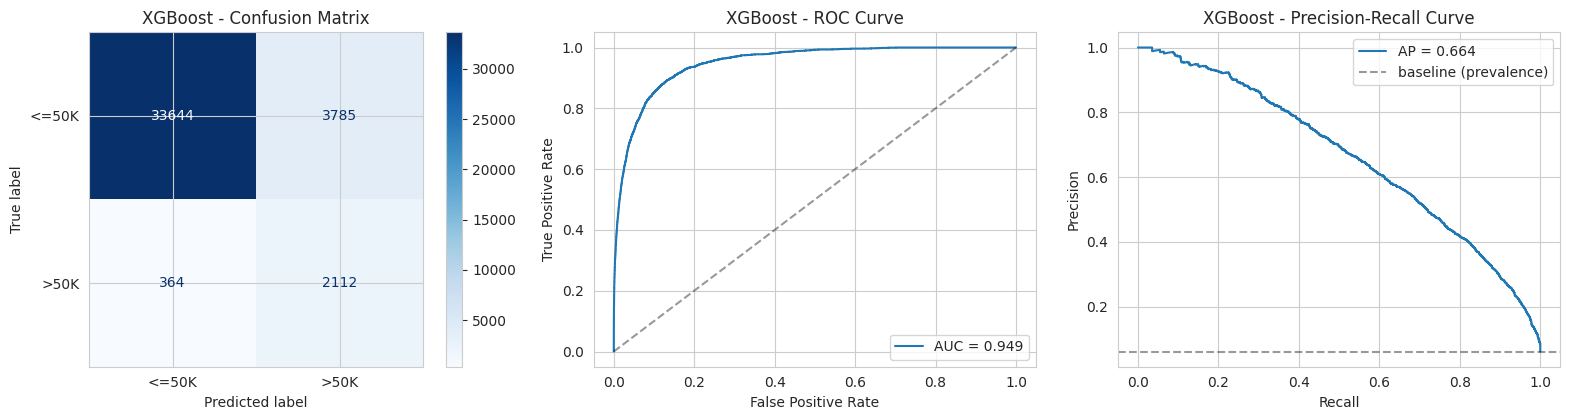

In [ ]:
# Evaluate the tuned XGBoost model using the same evaluate_model() function
# used for Decision Tree (Section 5) and Random Forest (Section 6) - gives
# identical metrics, an identical 3-panel plot (confusion matrix / ROC /
# precision-recall curve), and populates the shared `results` dict directly,
# so no separate backfill step is needed ahead of Section 8.
best_xgb = xgb_grid.best_estimator_
_ = evaluate_model('XGBoost', best_xgb, X_test_encoded, y_test)

**Result:** Test accuracy **0.896** - below the 93.79% naive baseline,
expected given `scale_pos_weight=15.113` deliberately trades accuracy for
minority-class recall, not a flaw. Confusion matrix: 33,644 true negatives,
3,785 false positives, 364 false negatives, 2,112 true positives. Minority
class (`>$50K`): precision 0.36, recall **0.85** (2,112/2,476 caught), F1
0.50 - the model is deliberately tuned to rarely miss a `>$50K` earner, at
the cost of a high false-positive rate.

**AUC = 0.949** - strong. This is the most important number in this
section: it shows the model is very good at *ranking* people by likelihood
of earning `>$50K`, independent of where the decision threshold sits. The
weak 0.36 precision above is a threshold/tradeoff effect from
`scale_pos_weight`, not evidence of a weak model - the underlying
discriminative ability is clearly strong.

**Avg Precision (area under the PR curve): 0.664** - the highest of all
three models (Decision Tree 0.544, Random Forest 0.589, XGBoost 0.664),
tracking the same improving trend seen in AUC (0.903 -> 0.942 -> 0.949).
Given how skewed the target is (6.21% positive class), AP arguably tells a
more demanding story than AUC here, since it doesn't get credit for
correctly ranking the negatives that were already easy - the fact that
XGBoost improves on *both* metrics together, rather than trading one for
the other, is stronger evidence of genuine improvement than either alone.

In [ ]:
# Feature importance from XGBoost - top 20 shown given the 282-column feature space
xgb_importance = pd.DataFrame({
    "Feature": X_train_encoded.columns,
    "Importance": best_xgb.feature_importances_
}).sort_values(by="Importance", ascending=False)

xgb_importance.head(20)

,Feature,Importance
108,FILESTAT_ Nonfiler,0.163752
5,WKSWORK,0.071085
90,ASEX_ Male,0.036138
69,AMJOCC_ Other service,0.026851
64,AMJOCC_ Executive admin and managerial,0.025228
72,AMJOCC_ Professional specialty,0.020915
27,AHGA_ High school graduate,0.017350
1,CAPGAIN,0.016956
30,AHGA_ Prof school degree (MD DDS DVM LLB JD),0.016552
3,DIVVAL,0.016290


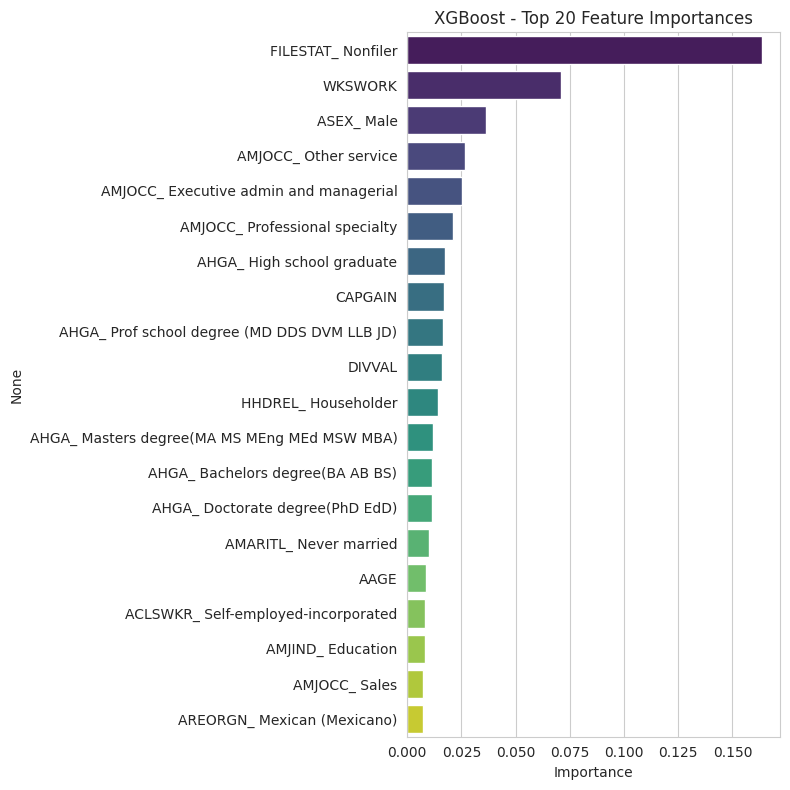

FILESTAT_ Nonfiler                              0.163752
WKSWORK                                         0.071085
ASEX_ Male                                      0.036138
AMJOCC_ Other service                           0.026851
AMJOCC_ Executive admin and managerial          0.025228
AMJOCC_ Professional specialty                  0.020915
AHGA_ High school graduate                      0.017350
CAPGAIN                                         0.016956
AHGA_ Prof school degree (MD DDS DVM LLB JD)    0.016552
DIVVAL                                          0.016290
HHDREL_ Householder                             0.014094
AHGA_ Masters degree(MA MS MEng MEd MSW MBA)    0.012045
AHGA_ Bachelors degree(BA AB BS)                0.011399
AHGA_ Doctorate degree(PhD EdD)                 0.011388
AMARITL_ Never married                          0.009890
AAGE                                            0.008637
ACLSWKR_ Self-employed-incorporated             0.008394
AMJIND_ Education              

In [ ]:
xgb_importances = pd.Series(best_xgb.feature_importances_, index=X_train_encoded.columns.to_list()).sort_values(ascending=False)
top_n = 20
plt.figure(figsize=(8, 8))
sns.barplot(x=xgb_importances.head(top_n).values, y=xgb_importances.head(top_n).index,
            hue=xgb_importances.head(top_n).index, palette='viridis', legend=False)
plt.title(f'XGBoost - Top {top_n} Feature Importances')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()
print(xgb_importances.head(top_n))

### Learning Curve - Does XGBoost Need More Training Data?

Tests whether the current training set size (159,618 rows) is already enough
for this model, or whether performance is still climbing at the full size.
Run with `cv=3` and capped `n_jobs` (not 5-fold / `-1`), consistent with the
memory constraints encountered earlier in this section - this still gives a
reliable read on the shape of the curve without repeating the earlier crash.

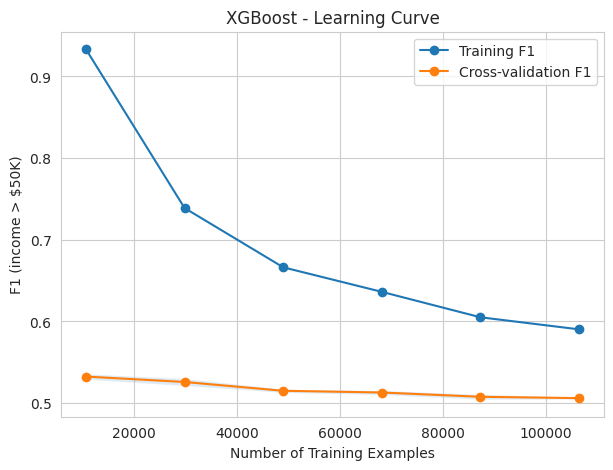

CV F1 at largest training size: 0.506 +/- 0.0011
CV F1 at smallest training size: 0.5324 +/- 0.0032


In [ ]:
train_sizes_xgb, train_scores_xgb, val_scores_xgb = learning_curve(
    XGBClassifier(**xgb_grid.best_params_, scale_pos_weight=scale_pos_weight_value,
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=2),
    X_train_encoded, y_train,
    cv=3,
    scoring="f1",
    train_sizes=np.linspace(0.1, 1.0, 6),  # 6 points instead of 8 - fewer total fits
    n_jobs=2   # capped, not -1
)

train_mean_xgb = train_scores_xgb.mean(axis=1)
val_mean_xgb = val_scores_xgb.mean(axis=1)
val_std_xgb = val_scores_xgb.std(axis=1)

plt.figure(figsize=(7, 5))
plt.plot(train_sizes_xgb, train_mean_xgb, "o-", label="Training F1")
plt.plot(train_sizes_xgb, val_mean_xgb, "o-", label="Cross-validation F1")
plt.fill_between(train_sizes_xgb, val_mean_xgb - val_std_xgb, val_mean_xgb + val_std_xgb, alpha=0.15)
plt.xlabel("Number of Training Examples")
plt.ylabel("F1 (income > $50K)")
plt.title("XGBoost - Learning Curve")
plt.legend()
plt.show()

print("CV F1 at largest training size:", round(val_mean_xgb[-1], 4), "+/-", round(val_std_xgb[-1], 4))
print("CV F1 at smallest training size:", round(val_mean_xgb[0], 4), "+/-", round(val_std_xgb[0], 4))

### Learning Curve Result

CV F1 was **0.5324 (+/- 0.0032)** at the smallest training size and
**0.5060 (+/- 0.0011)** at the full training size - a small, counter-intuitive
dip rather than the typical rising-then-plateauing shape. The full-size
result exactly matches the randomized search's reported CV F1, confirming
consistency in the pipeline. The dip is most plausibly attributable to (a)
hyperparameters that were tuned on the full training set and not re-optimized
at each point on the curve, and (b) noisier estimates at the smallest size,
evidenced directly by the ~3x tighter standard deviation at full size (0.0011
vs. 0.0032) - smaller, noisier minority-class samples driving less reliable
F1 at that end. This is not read as evidence that additional training data
would hurt the model; rather, the curve doesn't show a clear, still-climbing
trend that would argue for needing *more* data than the current 80/20 split
already provides.

---

## 8. Model Comparison

evaluated identically via the shared `evaluate_model()`

In [ ]:
comparison_df = pd.DataFrame(results).T.sort_values('f1', ascending=False)
comparison_df.round(4)

,accuracy,precision,recall,f1,roc_auc,avg_precision
XGBoost,0.8960,0.3581,0.8530,0.5045,0.9495,0.6642
Random Forest,0.8603,0.2918,0.8772,0.4379,0.9416,0.5894
Decision Tree,0.8439,0.2645,0.8514,0.4036,0.9030,0.5440


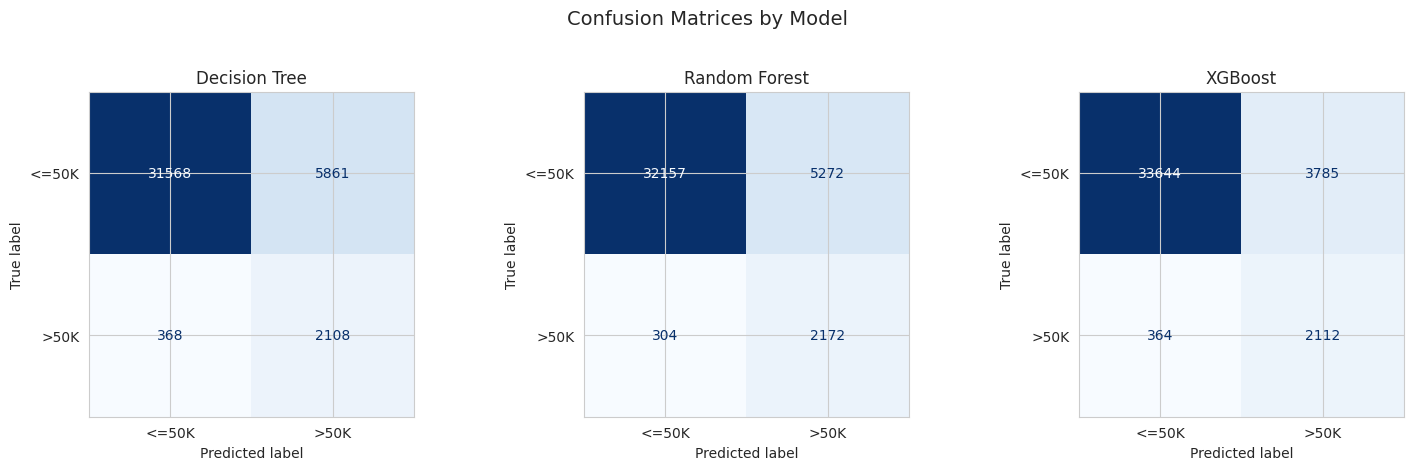

In [ ]:
models_for_comparison = {
    'Decision Tree': dt_final,
    'Random Forest': rf_final,
    'XGBoost': best_xgb
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, model) in zip(axes, models_for_comparison.items()):
    y_pred = model.predict(X_test_encoded)
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred, display_labels=['<=50K', '>50K'],
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(name)
plt.suptitle('Confusion Matrices by Model', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

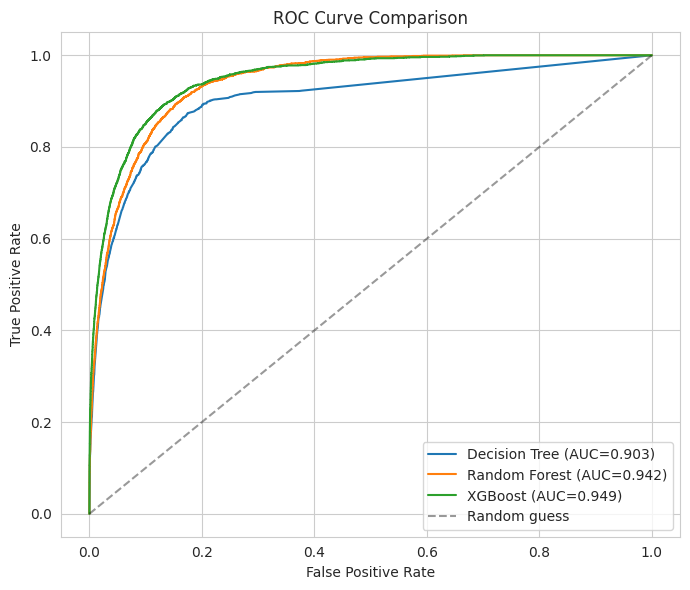

In [ ]:
plt.figure(figsize=(7, 6))
for name, model in models_for_comparison.items():
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

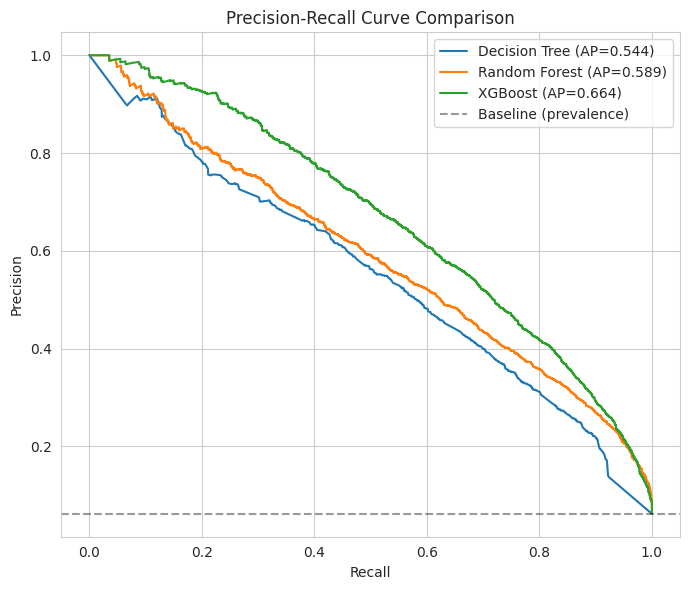

In [ ]:
plt.figure(figsize=(7, 6))
for name, model in models_for_comparison.items():
    y_proba = model.predict_proba(X_test_encoded)[:, 1]
    prec_curve, rec_curve, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    plt.plot(rec_curve, prec_curve, label=f'{name} (AP={ap:.3f})')
plt.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label='Baseline (prevalence)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

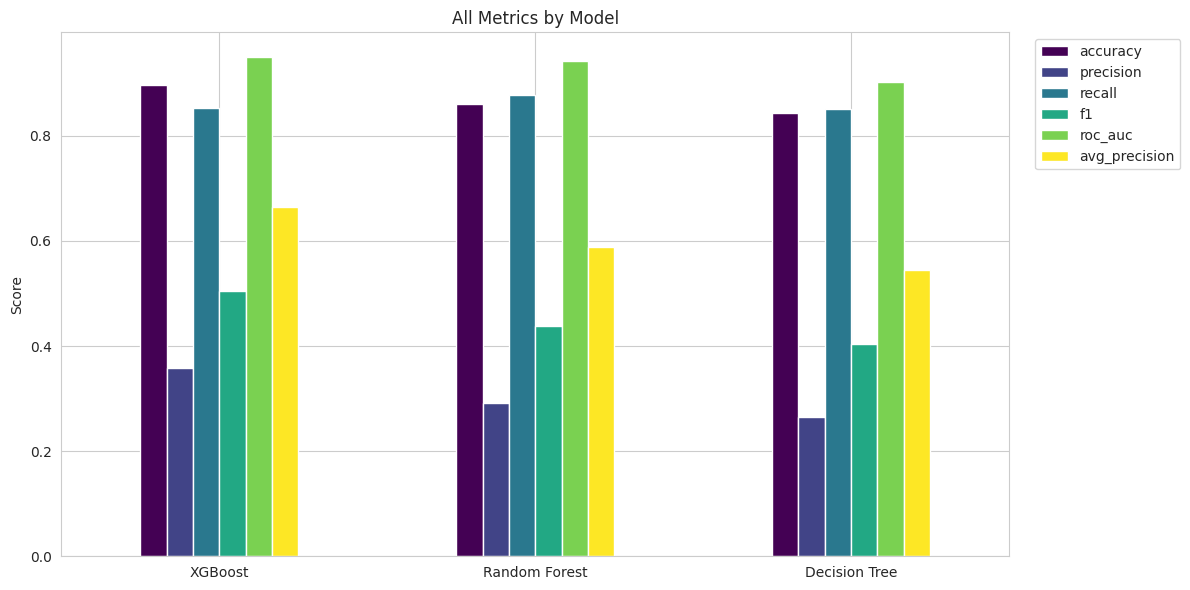

In [ ]:
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'avg_precision']
comparison_df[metrics_to_plot].plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.ylabel('Score')
plt.title('All Metrics by Model')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Bar chart shows pretty similar final metrics, not great for visualiztion

opted for table in report and slides

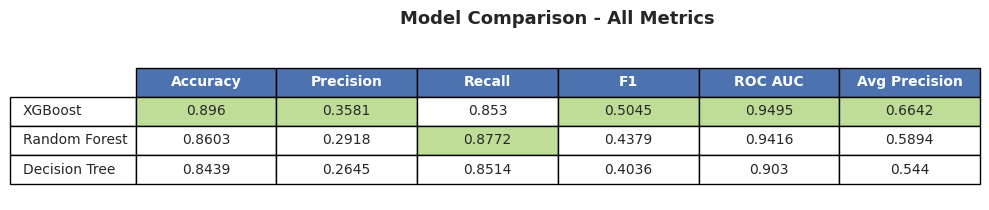

In [ ]:
# Comparison table rendered as a matplotlib table, same style as the
# Feature Dictionary table in Section 1 - highlights the best score per
# metric (column) rather than color-coding by model
display_df = comparison_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'avg_precision']].round(4)
display_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC', 'Avg Precision']

fig, ax = plt.subplots(figsize=(10, 2.2))
ax.axis("off")

# Color each cell: light green if it's the best (max) value in its column, else white
cell_colors = []
for model in display_df.index:
    row_colors = []
    for col in display_df.columns:
        is_best = display_df.loc[model, col] == display_df[col].max()
        row_colors.append("#C0DD97" if is_best else "#FFFFFF")
    cell_colors.append(row_colors)

table = ax.table(
    cellText=display_df.values,
    rowLabels=display_df.index,
    colLabels=display_df.columns,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for j in range(len(display_df.columns)):
    table[(0, j)].set_facecolor("#4C72B0")
    table[(0, j)].set_text_props(color="white", weight="bold")

plt.title("Model Comparison - All Metrics", fontsize=13, weight="bold", pad=20)
plt.tight_layout()
plt.show()